# Reliance Industries Stock Price Analysis & Next-Day Forecasting

## Objective

The aim of this notebook is to understand the Reliance Industries stock data.

We will:
- understand the data
- check missing values and duplicates
- find basic statistics
- study price and volume
- find outliers
- see price trends
- calculate daily returns
- study volatility
- check relationships between columns
## EDA Steps
1. Import libraries
2. Load data
3. View data
4. Check rows and columns
5. Check data types
6. Check missing values
7. Check duplicate rows
8. Check dates
9. Basic statistics
10. Study price distribution
11. Find outliers
12. Study price trend
13. Calculate moving averages
14. Calculate daily returns
15. Study volatility
16. Study volume
17. Check correlation
18. Find highest and lowest prices
19. Write EDA findings

## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Data
The Excel file contains the Reliance Industries stock data.

In [2]:
df = pd.read_excel("/Users/BANOTHU VINOD KUMAR/OneDrive/Desktop/dataset/Company stock prices.xlsx", sheet_name="in")
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
1,2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2,2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
3,2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
4,2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


## 
3. View First and Last Rows

In [3]:
print("First 5 rows")
display(df.head())
print("Last 5 rows")
display(df.tail())

First 5 rows


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
1,2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2,2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
3,2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
4,2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


Last 5 rows


,Date,Open,High,Low,Close,Adj Close,Volume
748,2023-10-10,385.579987,388.700012,372.250000,373.320007,373.320007,7288900
749,2023-10-11,372.779999,377.809998,365.339996,365.929993,365.929993,9151400
750,2023-10-12,366.480011,368.829987,359.049988,361.200012,361.200012,7376100
751,2023-10-13,355.640015,358.929993,352.049988,355.679993,355.679993,6312600
752,2023-10-16,356.209991,363.079987,354.769989,360.820007,360.820007,5119100


## 4. Check Rows and Columns
This tells us the size of the data.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 753
Number of columns: 7


## 5. Check Column Names

In [5]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


### Observation — Dataset Structure
- The dataset contains **753 rows and 7 columns**.
- The columns represent Date, Open, High, Low, Close, Adjusted Close and Volume.
- The Date column is stored as `datetime64[ns]`, while price columns are numeric.
- The structure is suitable for time-series analysis and forecasting.


## 6. Check Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       753 non-null    datetime64[ns]
 1   Open       753 non-null    float64       
 2   High       753 non-null    float64       
 3   Low        753 non-null    float64       
 4   Close      753 non-null    float64       
 5   Adj Close  753 non-null    float64       
 6   Volume     753 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 41.3 KB


## 7.Check Missing Values 

In [7]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### Observation — Missing Values
- No missing values were found in the original dataset.
- Therefore, no imputation was required for the raw data.
- Missing values introduced later by lag, rolling mean, volatility and technical-indicator calculations are expected and are removed before modeling.


In [8]:
for col in df.columns:
    print(col)
    print(df[col].unique())

Date
<DatetimeArray>
['2020-10-19 00:00:00', '2020-10-20 00:00:00', '2020-10-21 00:00:00',
 '2020-10-22 00:00:00', '2020-10-23 00:00:00', '2020-10-26 00:00:00',
 '2020-10-27 00:00:00', '2020-10-28 00:00:00', '2020-10-29 00:00:00',
 '2020-10-30 00:00:00',
 ...
 '2023-10-03 00:00:00', '2023-10-04 00:00:00', '2023-10-05 00:00:00',
 '2023-10-06 00:00:00', '2023-10-09 00:00:00', '2023-10-10 00:00:00',
 '2023-10-11 00:00:00', '2023-10-12 00:00:00', '2023-10-13 00:00:00',
 '2023-10-16 00:00:00']
Length: 753, dtype: datetime64[ns]
Open
[537.070007 528.140015 501.029999 494.690002 488.109985 487.029999
 490.01001  486.359985 488.5      502.01001  478.869995 484.929993
 495.359985 506.559998 515.       485.540009 470.950012 483.
 491.       486.769989 480.       480.119995 481.950012 482.
 485.220001 490.459991 478.839996 485.130005 486.579987 490.079987
 492.339996 501.619995 502.98999  497.5      500.01001  517.900024
 510.529999 494.559998 495.       505.440002 518.5      520.109985
 529.    

### Observation — Date Coverage
- The dataset covers approximately **October 2020 to October 2023**.
- The data is organized by trading dates rather than calendar days, which is appropriate for stock-market forecasting.
- Chronological ordering must be preserved throughout train/test splitting and validation.


## 8. Check Duplicate Rows

In [9]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## 9. Check Date
We check the first date, last date, and number of dates.

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Number of dates:", df["Date"].nunique())


Start date: 2020-10-19 00:00:00
End date: 2023-10-16 00:00:00
Number of dates: 753


##  Convert Date Column

We convert the Date column into date format so that we can use it for time-based analysis.

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

## 10. Basic Statistics

In [12]:
df.describe()


,Date,Open,High,Low,Close,Adj Close,Volume
count,753,753.000000,753.000000,753.000000,753.000000,753.000000,7.530000e+02
mean,2022-04-17 10:23:25.577689344,414.903107,421.117954,408.519270,414.796653,414.796653,7.060370e+06
min,2020-10-19 00:00:00,163.960007,172.059998,162.710007,166.369995,166.369995,1.144000e+06
25%,2021-07-20 00:00:00,311.570007,319.799988,308.850006,313.480011,313.480011,3.629200e+06
50%,2022-04-18 00:00:00,418.399994,425.260010,411.880005,416.029999,416.029999,5.277700e+06
75%,2023-01-17 00:00:00,519.900024,526.380005,513.789978,519.780029,519.780029,7.973300e+06
max,2023-10-16 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,1.333875e+08
std,NaN,135.039753,135.568500,134.016834,134.669664,134.669664,7.470407e+06


## 11. Closing Price Distribution

We use a histogram to understand the distribution of closing prices.

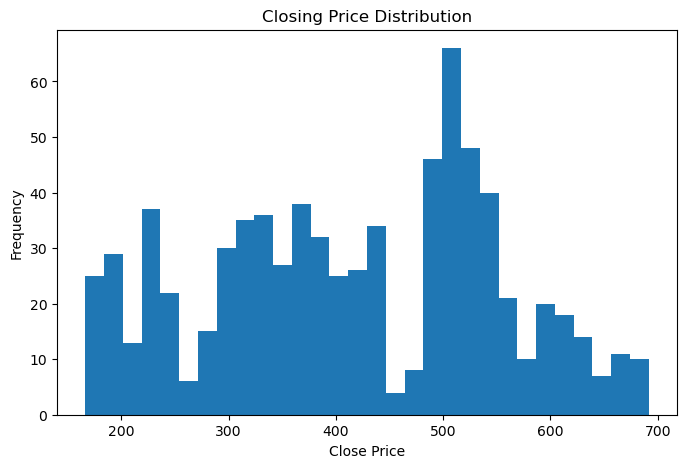

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Close"], bins=30)

plt.title("Closing Price Distribution")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

## 12. Closing Price Boxplot
A boxplot helps us understand the spread of the closing price and identify possible outliers.

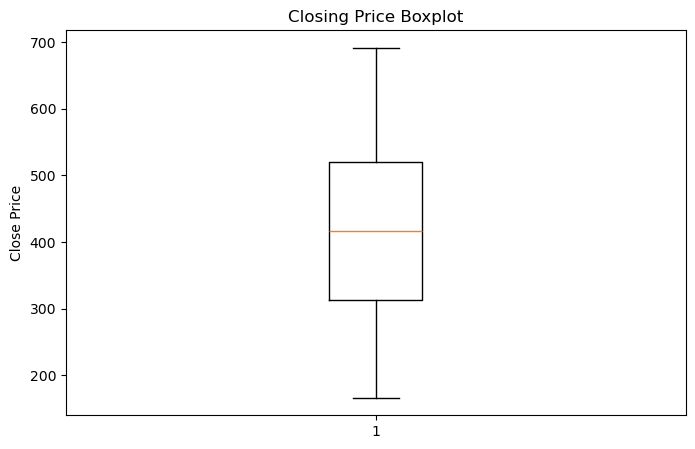

In [14]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Close"])

plt.title("Closing Price Boxplot")
plt.ylabel("Close Price")

plt.show()

## 13. Find Outliers Using IQR

We use the IQR method to identify possible outliers in the closing price.

In [15]:
Q1 = df["Close"].quantile(0.25)
Q3 = df["Close"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 4.029983999999956
Upper Limit: 829.2300560000001


## 14. Display Outliers

We display the rows where the closing price is outside the calculated limits.

In [16]:
outliers = df[
    (df["Close"] < lower_limit) |
    (df["Close"] > upper_limit)
]

outliers

,Date,Open,High,Low,Close,Adj Close,Volume


### 16. Study Volume
### We look at how trading volume behaved over time and its distribution.

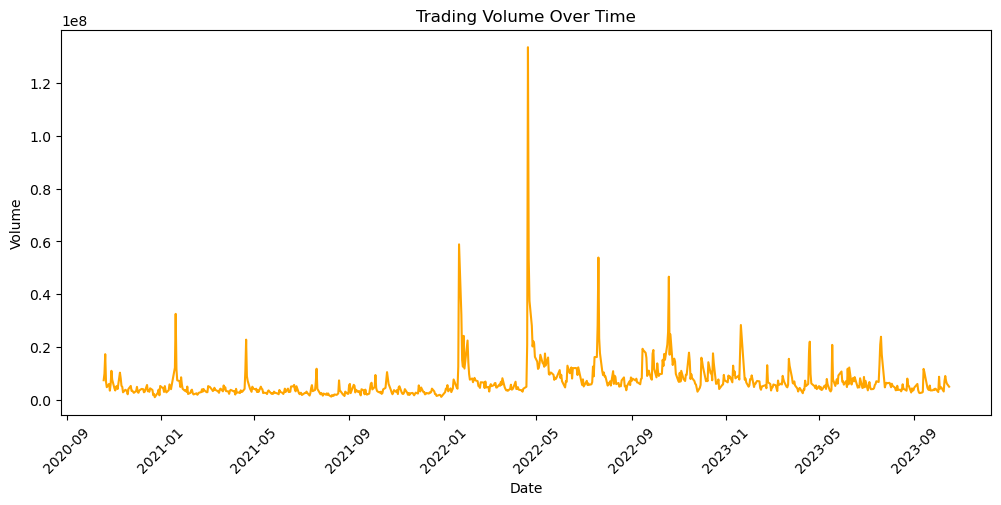

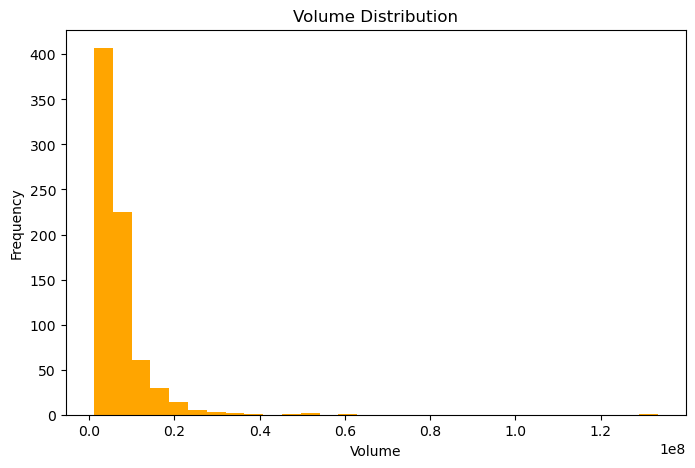

Average volume: 7060370.252324037
Max volume: 133387500 on 2022-04-20 00:00:00
Min volume: 1144000 on 2020-12-24 00:00:00


In [17]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Volume"], color="orange")
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Volume"], bins=30, color="orange")
plt.title("Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

print("Average volume:", df["Volume"].mean())
print("Max volume:", df["Volume"].max(), "on", df.loc[df["Volume"].idxmax(), "Date"])
print("Min volume:", df["Volume"].min(), "on", df.loc[df["Volume"].idxmin(), "Date"])


#### 17. Check Correlation
#### We check how price and volume columns relate to each other.


               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999187  0.999223  0.998184   0.998184 -0.391318
High       0.999187  1.000000  0.999152  0.999224   0.999224 -0.383515
Low        0.999223  0.999152  1.000000  0.999233   0.999233 -0.400809
Close      0.998184  0.999224  0.999233  1.000000   1.000000 -0.390191
Adj Close  0.998184  0.999224  0.999233  1.000000   1.000000 -0.390191
Volume    -0.391318 -0.383515 -0.400809 -0.390191  -0.390191  1.000000


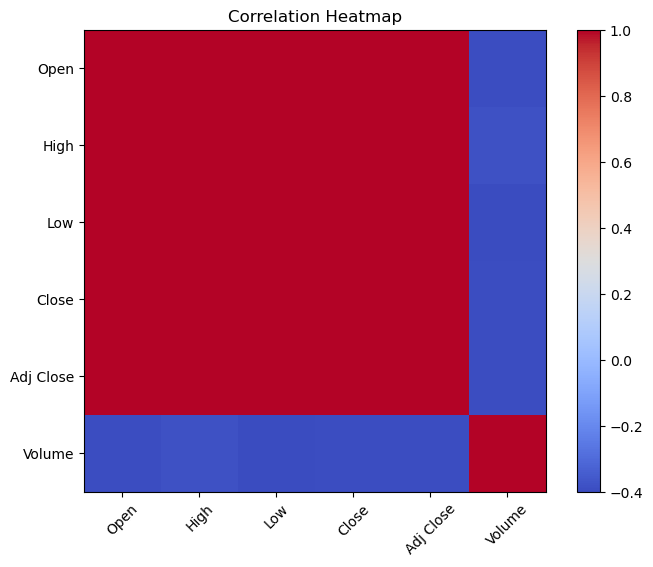

In [18]:
corr = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr()
print(corr)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()



#### 18. Find Highest and Lowest Prices

In [19]:
highest_close = df.loc[df["Close"].idxmax()]
lowest_close = df.loc[df["Close"].idxmin()]

print("Highest Close Price:")
print(highest_close[["Date", "Close"]])

print("\nLowest Close Price:")
print(lowest_close[["Date", "Close"]])

Highest Close Price:
Date     2021-11-17 00:00:00
Close             691.690002
Name: 273, dtype: object

Lowest Close Price:
Date     2022-05-11 00:00:00
Close             166.369995
Name: 393, dtype: object


## Feature Engineering

### Lag Features


In [20]:
df["Close_Lag1"] = df["Close"].shift(1)
df["Close_Lag2"] = df["Close"].shift(2)
df["Close_Lag3"] = df["Close"].shift(3)
df["Close_Lag5"] = df["Close"].shift(5)

In [21]:
df["MA_5"]  = df["Close"].rolling(5).mean()
df["MA_10"] = df["Close"].rolling(10).mean()
df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

### Exponential Moving Average

In [22]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

### Daily Return and Rolling Volatility

In [23]:
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_10"] = df["Daily_Return"].rolling(10).std()
df["Volatility_20"] = df["Daily_Return"].rolling(20).std()

### RSI (14-day)

In [24]:
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

### MACD (12, 26, 9)

In [25]:
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = ema12 - ema26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

### Bollinger Bands (20-day, 2 std)

In [26]:
df["BB_Mid"] = df["Close"].rolling(20).mean()
df["BB_Std"] = df["Close"].rolling(20).std()
df["BB_Upper"] = df["BB_Mid"] + (2 * df["BB_Std"])
df["BB_Lower"] = df["BB_Mid"] - (2 * df["BB_Std"])

### Price Range Features

In [27]:
df["High_Low_Range"] = df["High"] - df["Low"]
df["Open_Close_Range"] = df["Close"] - df["Open"]

### Volume-based Features

In [28]:
df["Volume_MA_10"] = df["Volume"].rolling(10).mean()
df["Volume_Change"] = df["Volume"].pct_change()

### Date-based Features

In [29]:
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

### Target Variable
# Target = `Close` price.

In [30]:
df["Target"] = df["Close"]

# Drop rows with NaN created by rolling/lag features
df_fe = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df_fe.shape)
df_fe.head()

Shape after feature engineering: (704, 34)


,Date,Open,High,Low,Close,Adj Close,Volume,Close_Lag1,Close_Lag2,Close_Lag3,...,BB_Upper,BB_Lower,High_Low_Range,Open_Close_Range,Volume_MA_10,Volume_Change,Day_of_Week,Month,Quarter,Target
0,2020-12-29,519.900024,536.549988,515.479980,530.869995,530.869995,4022400,519.119995,513.969971,514.479980,...,540.559766,489.360232,21.070008,10.969971,3102550.0,0.390919,1,12,4,530.869995
1,2020-12-30,530.130005,533.260010,523.690002,524.590027,524.590027,1876300,530.869995,519.119995,513.969971,...,541.415833,490.505169,9.570008,-5.539978,2950690.0,-0.533537,2,12,4,524.590027
2,2020-12-31,525.530029,545.500000,523.150024,540.729980,540.729980,5392300,524.590027,530.869995,519.119995,...,544.830469,490.825531,22.349976,15.199951,3121680.0,1.873901,3,12,4,540.729980
3,2021-01-04,539.000000,540.799988,515.090027,522.859985,522.859985,4444400,540.729980,524.590027,530.869995,...,544.410620,493.779379,25.709961,-16.140015,3246780.0,-0.175788,0,1,1,522.859985
4,2021-01-05,521.549988,526.780029,515.890015,520.799988,520.799988,3133900,522.859985,540.729980,524.590027,...,543.569395,496.869603,10.890014,-0.750000,3109900.0,-0.294865,1,1,1,520.799988


## Visualizations

### 1. Close vs Moving Averages

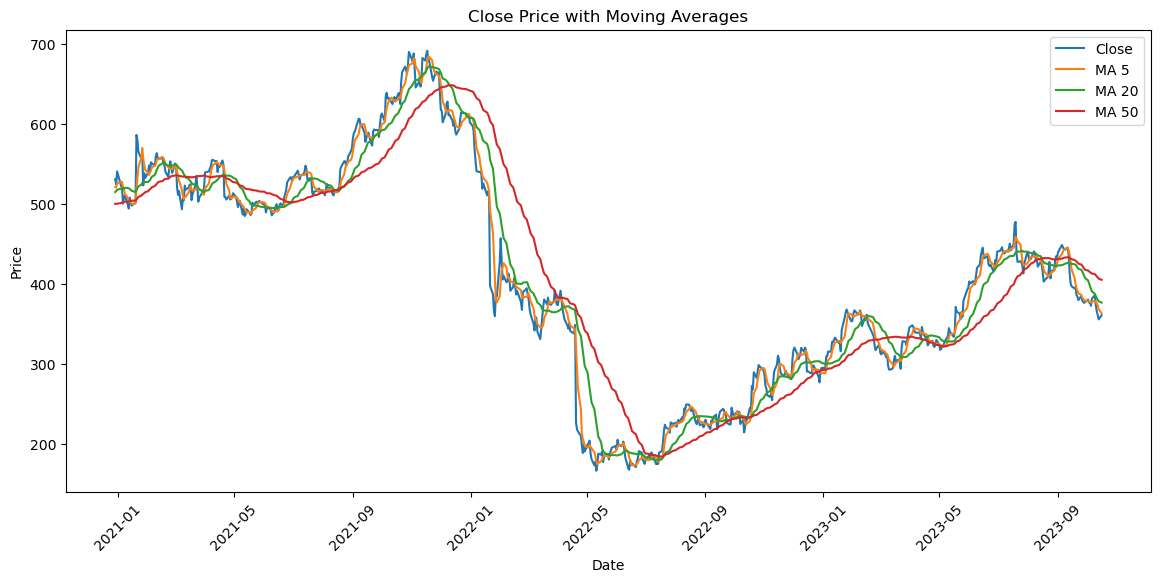

In [31]:
plt.figure(figsize=(14,6))
plt.plot(df_fe["Date"], df_fe["Close"], label="Close", linewidth=1.5)
plt.plot(df_fe["Date"], df_fe["MA_5"], label="MA 5")
plt.plot(df_fe["Date"], df_fe["MA_20"], label="MA 20")
plt.plot(df_fe["Date"], df_fe["MA_50"], label="MA 50")
plt.title("Close Price with Moving Averages")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 2. Close vs EMA

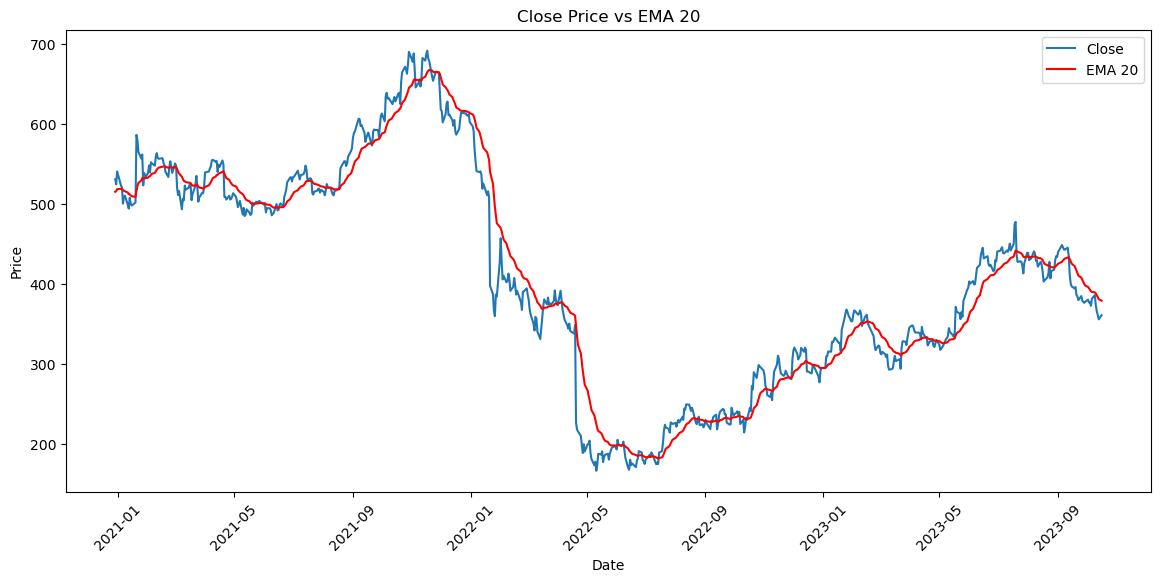

In [32]:
plt.figure(figsize=(14,6))
plt.plot(df_fe["Date"], df_fe["Close"], label="Close")
plt.plot(df_fe["Date"], df_fe["EMA_20"], label="EMA 20", color="red")
plt.title("Close Price vs EMA 20")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 3. Bollinger Bands

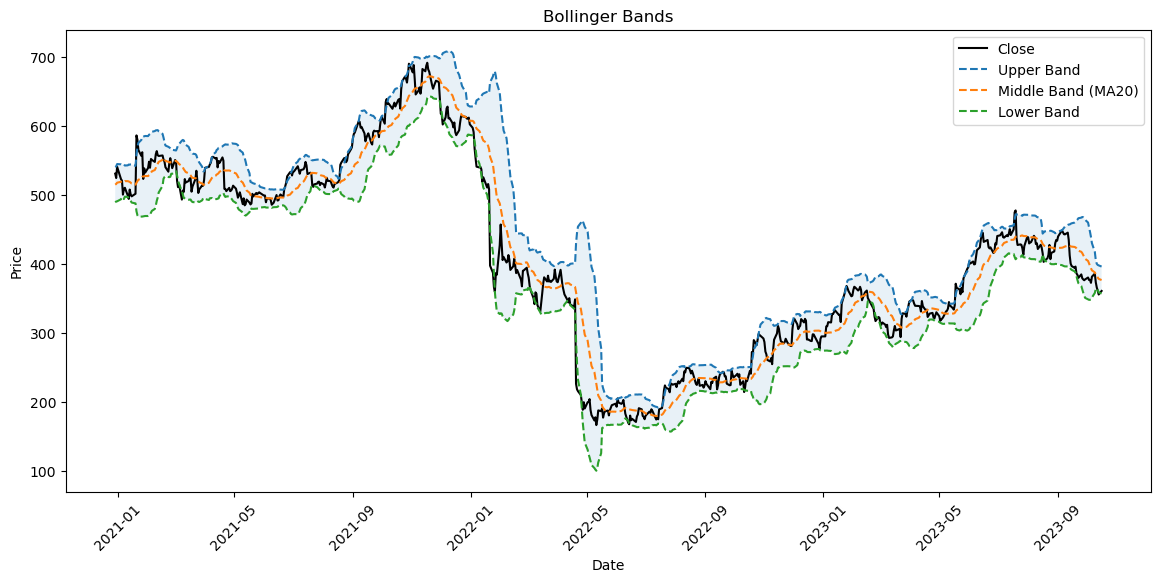

In [33]:
plt.figure(figsize=(14,6))
plt.plot(df_fe["Date"], df_fe["Close"], label="Close", color="black")
plt.plot(df_fe["Date"], df_fe["BB_Upper"], label="Upper Band", linestyle="--")
plt.plot(df_fe["Date"], df_fe["BB_Mid"], label="Middle Band (MA20)", linestyle="--")
plt.plot(df_fe["Date"], df_fe["BB_Lower"], label="Lower Band", linestyle="--")
plt.fill_between(df_fe["Date"], df_fe["BB_Upper"], df_fe["BB_Lower"], alpha=0.1)
plt.title("Bollinger Bands")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 4. RSI (14-day)

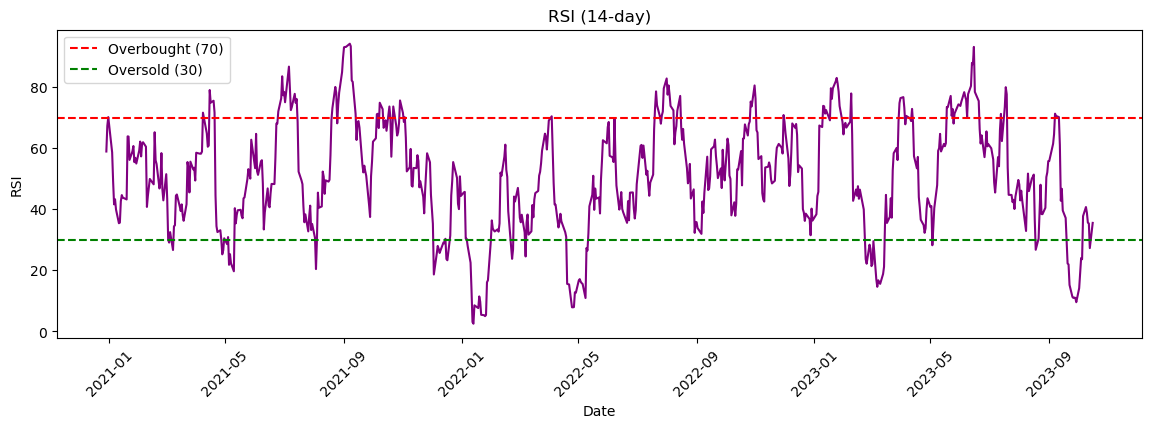

In [34]:
plt.figure(figsize=(14,4))
plt.plot(df_fe["Date"], df_fe["RSI_14"], color="purple")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title("RSI (14-day)")
plt.xlabel("Date"); plt.ylabel("RSI")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 5. MACD

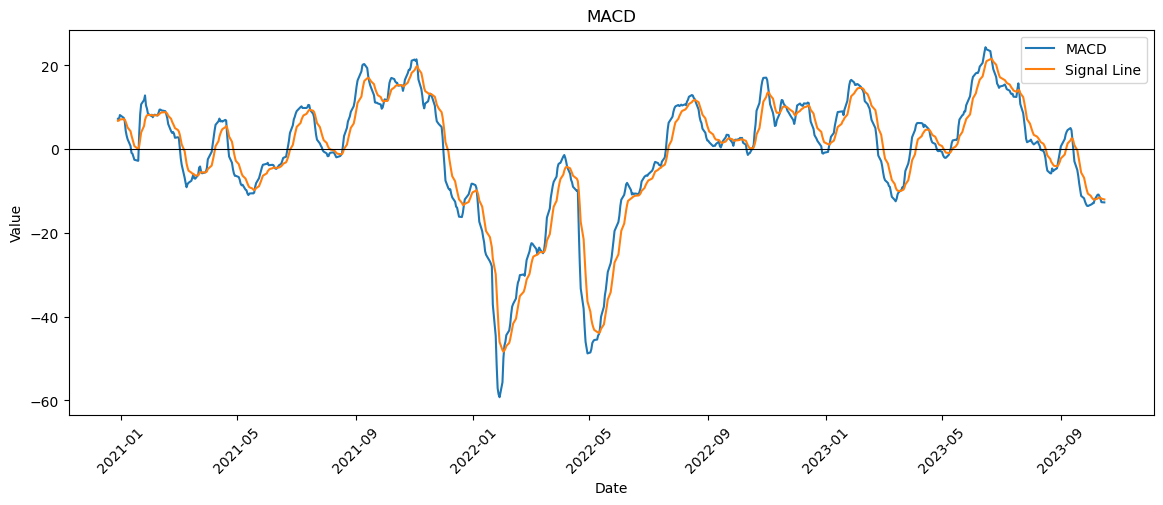

In [35]:
plt.figure(figsize=(14,5))
plt.plot(df_fe["Date"], df_fe["MACD"], label="MACD")
plt.plot(df_fe["Date"], df_fe["MACD_Signal"], label="Signal Line")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("MACD")
plt.xlabel("Date"); plt.ylabel("Value")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 6. Rolling Volatility

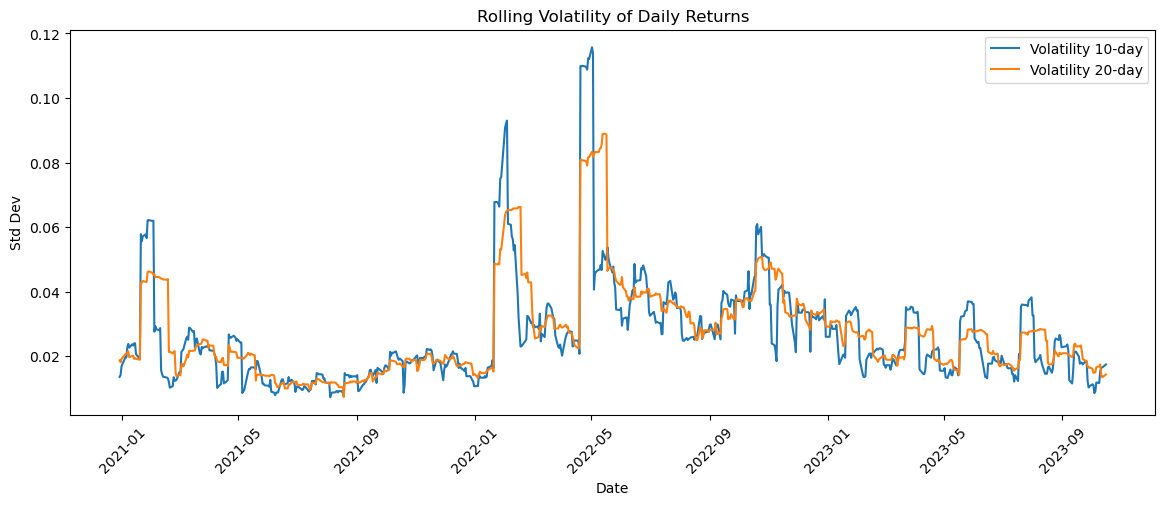

In [36]:
plt.figure(figsize=(14,5))
plt.plot(df_fe["Date"], df_fe["Volatility_10"], label="Volatility 10-day")
plt.plot(df_fe["Date"], df_fe["Volatility_20"], label="Volatility 20-day")
plt.title("Rolling Volatility of Daily Returns")
plt.xlabel("Date"); plt.ylabel("Std Dev")
plt.legend(); plt.xticks(rotation=45)
plt.show()

### 7. Correlation Heatmap: Engineered Features vs Target

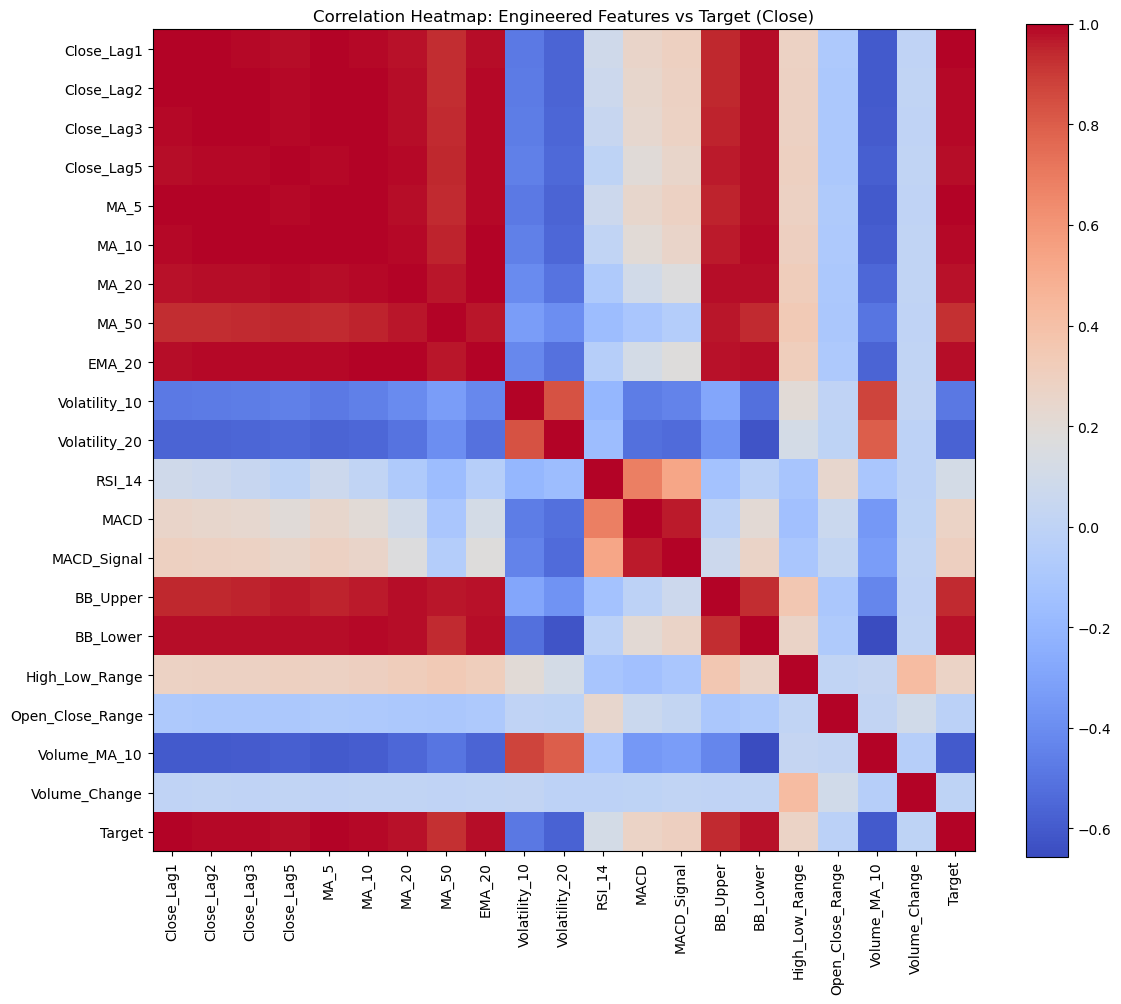

In [37]:
feature_cols = ["Close_Lag1","Close_Lag2","Close_Lag3","Close_Lag5",
                 "MA_5","MA_10","MA_20","MA_50","EMA_20",
                 "Volatility_10","Volatility_20","RSI_14","MACD","MACD_Signal",
                 "BB_Upper","BB_Lower","High_Low_Range","Open_Close_Range",
                 "Volume_MA_10","Volume_Change","Target"]

corr_matrix = df_fe[feature_cols].corr()

plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Correlation Heatmap: Engineered Features vs Target (Close)")
plt.tight_layout()
plt.show()


### 8. Feature Correlation with Target (Bar Chart)

Correlation of features with Target (Close):

Target              1.000000
Close_Lag1          0.996327
MA_5                0.995384
Close_Lag2          0.992383
MA_10               0.989275
Close_Lag3          0.988539
EMA_20              0.981376
Close_Lag5          0.980764
BB_Lower            0.979278
MA_20               0.975441
BB_Upper            0.938182
MA_50               0.925295
MACD_Signal         0.299061
High_Low_Range      0.273649
MACD                0.270739
RSI_14              0.114466
Volume_Change       0.001438
Open_Close_Range   -0.019962
Volatility_10      -0.486890
Volatility_20      -0.570926
Volume_MA_10       -0.603657
Name: Target, dtype: float64


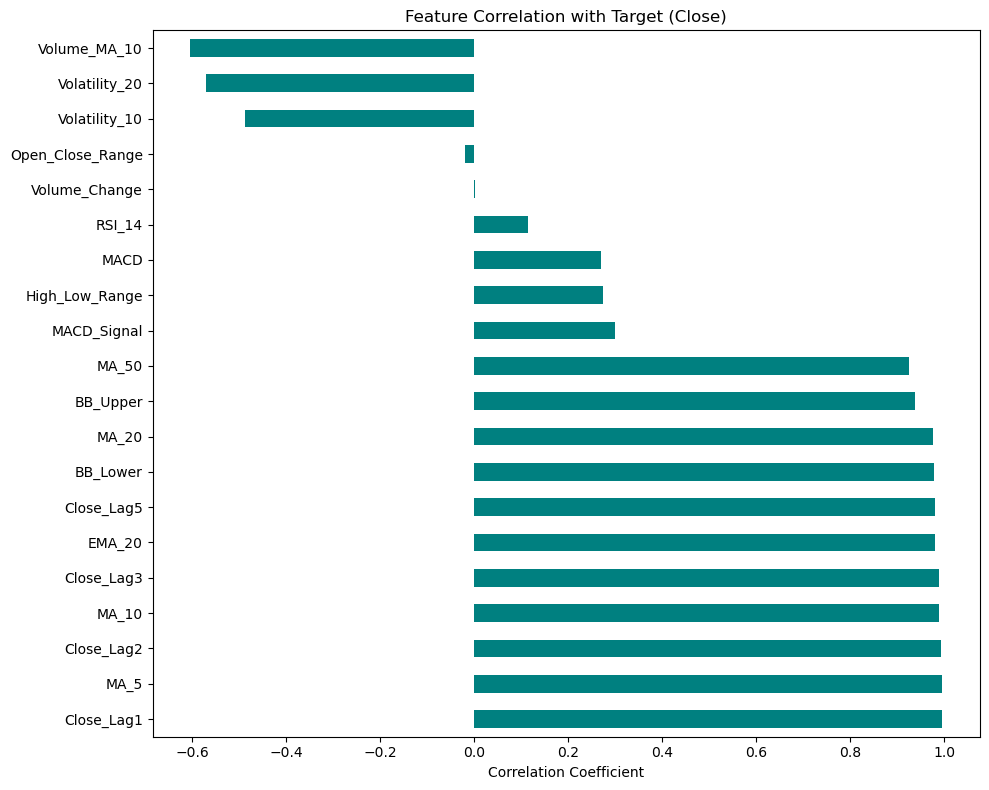

In [38]:
target_corr = corr_matrix["Target"].sort_values(ascending=False)
print("Correlation of features with Target (Close):\n")
print(target_corr)

plt.figure(figsize=(10,8))
target_corr.drop("Target").plot(kind="barh", color="teal")
plt.title("Feature Correlation with Target (Close)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

### Additional Feature 1: Daily Range Percentage

In [39]:
df["Daily_Range_Pct"] = ((df["High"] - df["Low"]) / df["Close"]) * 100
df[["Date", "High", "Low", "Close", "Daily_Range_Pct"]].head()

,Date,High,Low,Close,Daily_Range_Pct
0,2020-10-19,541.799988,525.380005,530.719971,3.093907
1,2020-10-20,533.780029,522.260010,525.419983,2.192535
2,2020-10-21,506.850006,488.250000,489.049988,3.803293
3,2020-10-22,495.140015,482.000000,485.230011,2.707997
4,2020-10-23,490.059998,481.350006,488.279999,1.783811


### Additional Feature 2: Open-to-Close Return

In [40]:
df["Open_Close_Return"] = ((df["Close"] - df["Open"]) / df["Open"]) * 100
df[["Date", "Open", "Close", "Open_Close_Return"]].head()

,Date,Open,Close,Open_Close_Return
0,2020-10-19,537.070007,530.719971,-1.182348
1,2020-10-20,528.140015,525.419983,-0.515021
2,2020-10-21,501.029999,489.049988,-2.391077
3,2020-10-22,494.690002,485.230011,-1.912307
4,2020-10-23,488.109985,488.279999,0.034831


### Additional Feature 3: Volume Ratio

In [41]:
df["Volume_Ratio"] = df["Volume"] / df["Volume_MA_10"]
df[["Date", "Volume", "Volume_MA_10", "Volume_Ratio"]].head()

,Date,Volume,Volume_MA_10,Volume_Ratio
0,2020-10-19,7567500,NaN,NaN
1,2020-10-20,10047200,NaN,NaN
2,2020-10-21,17405700,NaN,NaN
3,2020-10-22,6997900,NaN,NaN
4,2020-10-23,4927900,NaN,NaN


In [42]:
df["Target"] = df["Close"].shift(-1)

df_fe = df.dropna().reset_index(drop=True)
print("Shape after feature engineering and target preparation:", df_fe.shape)
df_fe.head()

Shape after feature engineering and target preparation: (703, 37)


,Date,Open,High,Low,Close,Adj Close,Volume,Close_Lag1,Close_Lag2,Close_Lag3,...,Open_Close_Range,Volume_MA_10,Volume_Change,Day_of_Week,Month,Quarter,Target,Daily_Range_Pct,Open_Close_Return,Volume_Ratio
0,2020-12-29,519.900024,536.549988,515.479980,530.869995,530.869995,4022400,519.119995,513.969971,514.479980,...,10.969971,3102550.0,0.390919,1,12,4,524.590027,3.968958,2.110015,1.296482
1,2020-12-30,530.130005,533.260010,523.690002,524.590027,524.590027,1876300,530.869995,519.119995,513.969971,...,-5.539978,2950690.0,-0.533537,2,12,4,540.729980,1.824283,-1.045023,0.635885
2,2020-12-31,525.530029,545.500000,523.150024,540.729980,540.729980,5392300,524.590027,530.869995,519.119995,...,15.199951,3121680.0,1.873901,3,12,4,522.859985,4.133297,2.892309,1.727371
3,2021-01-04,539.000000,540.799988,515.090027,522.859985,522.859985,4444400,540.729980,524.590027,530.869995,...,-16.140015,3246780.0,-0.175788,0,1,1,520.799988,4.917179,-2.994437,1.368864
4,2021-01-05,521.549988,526.780029,515.890015,520.799988,520.799988,3133900,522.859985,540.729980,524.590027,...,-0.750000,3109900.0,-0.294865,1,1,1,500.489990,2.091017,-0.143802,1.007717


## Feature Engineering — Observations
- Lag features capture recent historical price information.
- Moving averages and EMA capture short- and medium-term trends.
- RSI, MACD and Bollinger Bands provide technical-indicator information.
- Volatility and volume features capture market activity and risk.
- The target is correctly changed to **the next trading day's Close price** using `shift(-1)`.
- Rolling and lag features create initial `NaN` rows; these are removed before modeling.
- The final modeling dataset contains **703 usable observations and 35 predictor features**.


In [43]:
df_fe.isnull().sum().sort_values(ascending=False).head(20)

Date                 0
RSI_14               0
MACD_Signal          0
BB_Mid               0
BB_Std               0
BB_Upper             0
BB_Lower             0
High_Low_Range       0
Open_Close_Range     0
Volume_MA_10         0
Volume_Change        0
Day_of_Week          0
Month                0
Quarter              0
Target               0
Daily_Range_Pct      0
Open_Close_Return    0
MACD                 0
Volatility_20        0
Open                 0
dtype: int64

In [44]:
target_corr = (df_fe.select_dtypes(include="number").corr()["Target"].sort_values(ascending=False))
display(target_corr)

Target               1.000000
Close                0.996329
Adj Close            0.996329
Low                  0.995705
High                 0.995568
Open                 0.994660
Close_Lag1           0.992387
MA_5                 0.991518
Close_Lag2           0.988539
MA_10                0.985531
Close_Lag3           0.984542
EMA_20               0.977207
Close_Lag5           0.977135
BB_Lower             0.975939
BB_Mid               0.971248
MA_20                0.971248
BB_Upper             0.933321
MA_50                0.920211
MACD_Signal          0.302610
MACD                 0.273789
High_Low_Range       0.268819
RSI_14               0.118521
Quarter              0.082530
Month                0.074985
Daily_Return         0.030670
Volume_Ratio        -0.012473
Volume_Change       -0.013802
Day_of_Week         -0.014358
Open_Close_Range    -0.020798
BB_Std              -0.026809
Open_Close_Return   -0.029792
Volume              -0.390172
Volatility_10       -0.486500
Daily_Rang

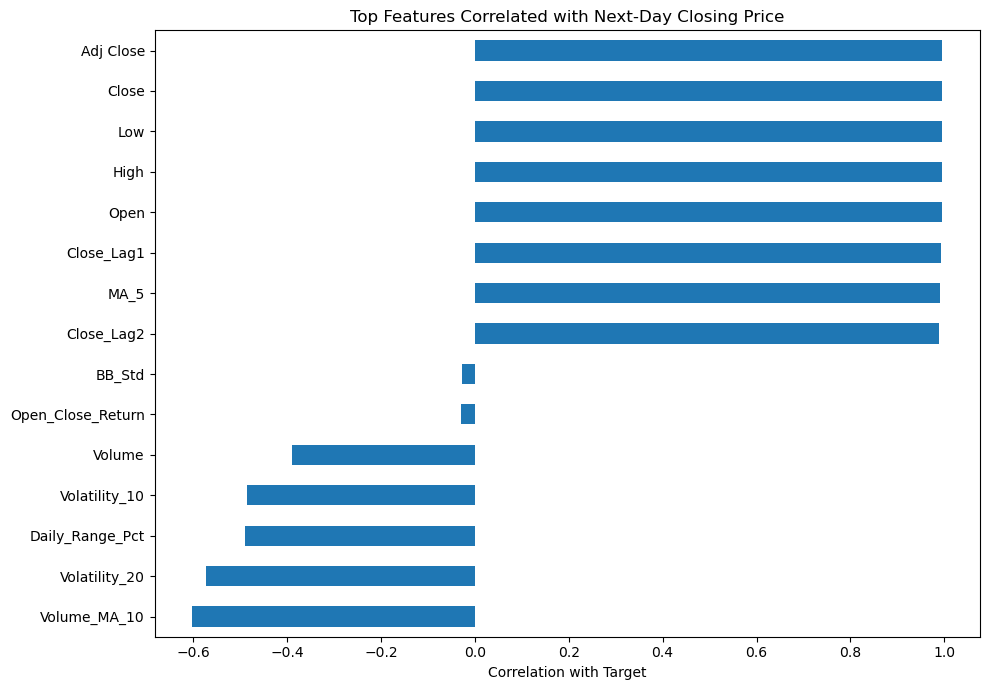

In [45]:
feature_corr = (df_fe.select_dtypes(include="number").corr()["Target"].drop("Target").sort_values())
top_features = pd.concat([feature_corr.head(7), feature_corr.tail(8)])
plt.figure(figsize=(10, 7))
top_features.plot(kind="barh")
plt.title("Top Features Correlated with Next-Day Closing Price")
plt.xlabel("Correlation with Target")
plt.tight_layout()
plt.show()

In [46]:
corr_matrix = df_fe.select_dtypes(include="number").corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        if abs(v) >= 0.90:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], v))
high_corr_pairs

[('Open', 'High', np.float64(0.999210678196193)),
 ('Open', 'Low', np.float64(0.9992565162893721)),
 ('Open', 'Close', np.float64(0.9982542392102741)),
 ('Open', 'Adj Close', np.float64(0.9982542392102741)),
 ('Open', 'Close_Lag1', np.float64(0.9984243347801139)),
 ('Open', 'Close_Lag2', np.float64(0.9947906754466556)),
 ('Open', 'Close_Lag3', np.float64(0.9909005048355249)),
 ('Open', 'Close_Lag5', np.float64(0.9833866612267137)),
 ('Open', 'MA_5', np.float64(0.9969112295142251)),
 ('Open', 'MA_10', np.float64(0.9912133028330838)),
 ('Open', 'MA_20', np.float64(0.9777726528864243)),
 ('Open', 'MA_50', np.float64(0.9283164408853243)),
 ('Open', 'EMA_20', np.float64(0.9835374259041626)),
 ('Open', 'BB_Mid', np.float64(0.9777726528864243)),
 ('Open', 'BB_Upper', np.float64(0.9410812185852354)),
 ('Open', 'BB_Lower', np.float64(0.9809536329940114)),
 ('Open', 'Target', np.float64(0.9946597959838321)),
 ('High', 'Low', np.float64(0.999198207182677)),
 ('High', 'Close', np.float64(0.9992727

In [47]:
X = df_fe.drop(columns=["Date", "Target"])
y = df_fe["Target"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

X shape: (703, 35)
y shape: (703,)

Features:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_20', 'Daily_Return', 'Volatility_10', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower', 'High_Low_Range', 'Open_Close_Range', 'Volume_MA_10', 'Volume_Change', 'Day_of_Week', 'Month', 'Quarter', 'Daily_Range_Pct', 'Open_Close_Return', 'Volume_Ratio']

Target:
Target


        RELIANCE INDUSTRIES - MODEL READINESS CHECK

1. DATASET INFORMATION
----------------------------------------------------------------------
Dataset Shape: (703, 37)
Number of Rows: 703
Number of Columns: 37

2. COLUMN NAMES
----------------------------------------------------------------------
1 : Date
2 : Open
3 : High
4 : Low
5 : Close
6 : Adj Close
7 : Volume
8 : Close_Lag1
9 : Close_Lag2
10 : Close_Lag3
11 : Close_Lag5
12 : MA_5
13 : MA_10
14 : MA_20
15 : MA_50
16 : EMA_20
17 : Daily_Return
18 : Volatility_10
19 : Volatility_20
20 : RSI_14
21 : MACD
22 : MACD_Signal
23 : BB_Mid
24 : BB_Std
25 : BB_Upper
26 : BB_Lower
27 : High_Low_Range
28 : Open_Close_Range
29 : Volume_MA_10
30 : Volume_Change
31 : Day_of_Week
32 : Month
33 : Quarter
34 : Target
35 : Daily_Range_Pct
36 : Open_Close_Return
37 : Volume_Ratio

3. DATA TYPES
----------------------------------------------------------------------


Date                 datetime64[ns]
Open                        float64
High                        float64
Low                         float64
Close                       float64
Adj Close                   float64
Volume                        int64
Close_Lag1                  float64
Close_Lag2                  float64
Close_Lag3                  float64
Close_Lag5                  float64
MA_5                        float64
MA_10                       float64
MA_20                       float64
MA_50                       float64
EMA_20                      float64
Daily_Return                float64
Volatility_10               float64
Volatility_20               float64
RSI_14                      float64
MACD                        float64
MACD_Signal                 float64
BB_Mid                      float64
BB_Std                      float64
BB_Upper                    float64
BB_Lower                    float64
High_Low_Range              float64
Open_Close_Range            


4. NUMERICAL AND NON-NUMERICAL COLUMNS
----------------------------------------------------------------------
Numerical Columns:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_20', 'Daily_Return', 'Volatility_10', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower', 'High_Low_Range', 'Open_Close_Range', 'Volume_MA_10', 'Volume_Change', 'Day_of_Week', 'Month', 'Quarter', 'Target', 'Daily_Range_Pct', 'Open_Close_Return', 'Volume_Ratio']

Non-Numerical Columns:
['Date']

5. MISSING VALUE CHECK
----------------------------------------------------------------------


Series([], dtype: int64)

✅ PASS: No missing values found.

6. DUPLICATE ROW CHECK
----------------------------------------------------------------------
Duplicate Rows: 0
✅ PASS: No duplicate rows found.

7. DATE CHECK
----------------------------------------------------------------------
Date Data Type: datetime64[ns]
Start Date: 2020-12-29 00:00:00
End Date: 2023-10-13 00:00:00
Dates Sorted: True
✅ PASS: Dates are in chronological order.

8. TARGET CHECK
----------------------------------------------------------------------
Target Column: Target
Target Data Type: float64
Target Missing Values: 0

Target Statistics:


...

✅ PASS: No infinite values found.

10. MODEL FEATURE TYPE CHECK
----------------------------------------------------------------------
Non-Numerical Model Features:
[]
✅ PASS: All model features are numerical.

11. ENCODING CHECK
----------------------------------------------------------------------
Categorical Columns Requiring Encoding:
[]
✅ PASS: No categorical features requiring encoding.
➡️ Label Encoding is NOT required.
➡️ One-Hot Encoding is NOT required.

12. X AND y CHECK
----------------------------------------------------------------------
X Shape: (703, 35)
y Shape: (703,)

Number of Features: 35
Number of Observations: 703
✅ PASS: X and y have the same number of rows.

13. FEATURE vs TARGET CORRELATION
----------------------------------------------------------------------


Target               1.000000
Close                0.996329
Adj Close            0.996329
Low                  0.995705
High                 0.995568
Open                 0.994660
Close_Lag1           0.992387
MA_5                 0.991518
Close_Lag2           0.988539
MA_10                0.985531
Close_Lag3           0.984542
EMA_20               0.977207
Close_Lag5           0.977135
BB_Lower             0.975939
BB_Mid               0.971248
MA_20                0.971248
BB_Upper             0.933321
MA_50                0.920211
MACD_Signal          0.302610
MACD                 0.273789
High_Low_Range       0.268819
RSI_14               0.118521
Quarter              0.082530
Month                0.074985
Daily_Return         0.030670
Volume_Ratio        -0.012473
Volume_Change       -0.013802
Day_of_Week         -0.014358
Open_Close_Range    -0.020798
BB_Std              -0.026809
Open_Close_Return   -0.029792
Volume              -0.390172
Volatility_10       -0.486500
Daily_Rang


14. MULTICOLLINEARITY CHECK
----------------------------------------------------------------------
Features with absolute correlation >= 0.90:


,Feature 1,Feature 2,Correlation
45,Close,Adj Close,1.000000
123,MA_20,BB_Mid,1.000000
18,High,Adj Close,0.999273
17,High,Close,0.999273
32,Low,Adj Close,0.999260
...,...,...,...
11,Open,MA_50,0.928316
26,High,MA_50,0.928085
65,Adj Close,MA_50,0.925349
53,Close,MA_50,0.925349



15. TARGET DISTRIBUTION
----------------------------------------------------------------------


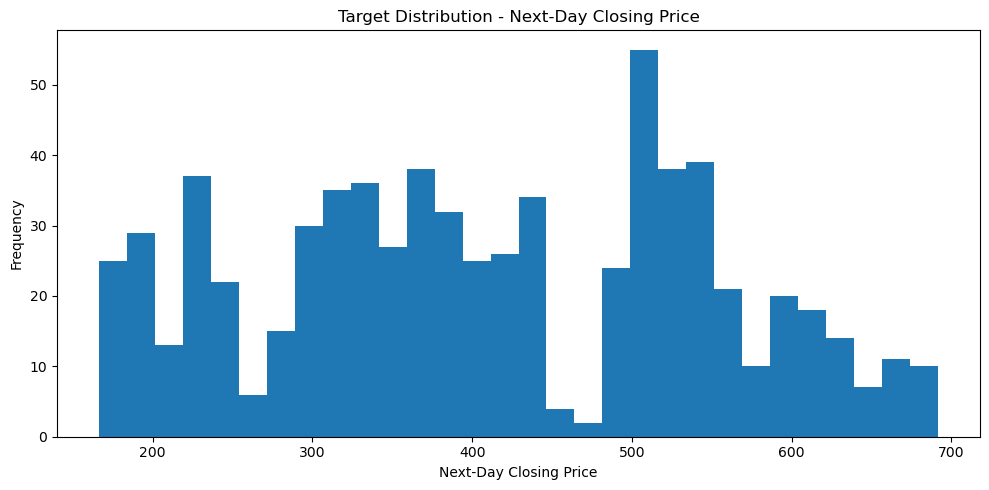



              FINAL READINESS CHECK


,Check,Status
0,No Missing Values,True
1,No Duplicate Rows,True
2,Target Exists,True
3,Target Has No Missing Values,True
4,Dates Sorted,True
5,All Model Features Numeric,True
6,No Infinite Values,True
7,X and y Same Length,True




✅ DATASET IS READY FOR MODELING

You can now move to the modeling stage.


In [48]:
# ================================================================
#        RELIANCE INDUSTRIES - MODEL READINESS CHECK
# ================================================================
# Purpose:
# Check whether the final feature-engineered dataset is clean
# and ready to move to the MODELING stage.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("        RELIANCE INDUSTRIES - MODEL READINESS CHECK")
print("=" * 70)


# ================================================================
# 1. CHECK DATASET
# ================================================================

print("\n1. DATASET INFORMATION")
print("-" * 70)

print("Dataset Shape:", df_fe.shape)
print("Number of Rows:", df_fe.shape[0])
print("Number of Columns:", df_fe.shape[1])


# ================================================================
# 2. CHECK COLUMN NAMES
# ================================================================

print("\n2. COLUMN NAMES")
print("-" * 70)

for i, column in enumerate(df_fe.columns, 1):
    print(i, ":", column)


# ================================================================
# 3. CHECK DATA TYPES
# ================================================================

print("\n3. DATA TYPES")
print("-" * 70)

display(df_fe.dtypes)


# ================================================================
# 4. CHECK NUMERICAL / NON-NUMERICAL COLUMNS
# ================================================================

print("\n4. NUMERICAL AND NON-NUMERICAL COLUMNS")
print("-" * 70)

numeric_columns = df_fe.select_dtypes(
    include="number"
).columns.tolist()

non_numeric_columns = df_fe.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nNon-Numerical Columns:")
print(non_numeric_columns)


# ================================================================
# 5. CHECK MISSING VALUES
# ================================================================

print("\n5. MISSING VALUE CHECK")
print("-" * 70)

missing_values = df_fe.isnull().sum()

display(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

if missing_values.sum() == 0:
    print("✅ PASS: No missing values found.")
else:
    print("❌ FAIL: Missing values found.")


# ================================================================
# 6. CHECK DUPLICATES
# ================================================================

print("\n6. DUPLICATE ROW CHECK")
print("-" * 70)

duplicate_count = df_fe.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

if duplicate_count == 0:
    print("✅ PASS: No duplicate rows found.")
else:
    print("❌ FAIL: Duplicate rows found.")


# ================================================================
# 7. CHECK DATE COLUMN
# ================================================================

print("\n7. DATE CHECK")
print("-" * 70)

if "Date" in df_fe.columns:

    print("Date Data Type:", df_fe["Date"].dtype)
    print("Start Date:", df_fe["Date"].min())
    print("End Date:", df_fe["Date"].max())

    dates_sorted = df_fe["Date"].is_monotonic_increasing

    print("Dates Sorted:", dates_sorted)

    if dates_sorted:
        print("✅ PASS: Dates are in chronological order.")
    else:
        print("❌ FAIL: Dates are not in chronological order.")

else:
    print("⚠️ Date column not found.")


# ================================================================
# 8. CHECK TARGET COLUMN
# ================================================================

print("\n8. TARGET CHECK")
print("-" * 70)

if "Target" in df_fe.columns:

    print("Target Column:", "Target")
    print("Target Data Type:", df_fe["Target"].dtype)
    print(
        "Target Missing Values:",
        df_fe["Target"].isnull().sum()
    )

    print("\nTarget Statistics:")
    display(df_fe["Target"].describe())

    if df_fe["Target"].isnull().sum() == 0:
        print("✅ PASS: Target has no missing values.")
    else:
        print("❌ FAIL: Target contains missing values.")

else:
    print("❌ FAIL: Target column is missing.")


# ================================================================
# 9. CHECK INFINITE VALUES
# ================================================================

print("\n9. INFINITE VALUE CHECK")
print("-" * 70)

numeric_data = df_fe.select_dtypes(
    include="number"
)

infinite_values = np.isinf(
    numeric_data
).sum()

display(
    infinite_values[
        infinite_values > 0
    ]
)

if infinite_values.sum() == 0:
    print("✅ PASS: No infinite values found.")
else:
    print("❌ FAIL: Infinite values found.")


# ================================================================
# 10. CHECK NON-NUMERICAL MODEL FEATURES
# ================================================================

print("\n10. MODEL FEATURE TYPE CHECK")
print("-" * 70)

if "Target" in df_fe.columns:
    model_features = df_fe.drop(
        columns=["Date", "Target"],
        errors="ignore"
    )
else:
    model_features = df_fe.drop(
        columns=["Date"],
        errors="ignore"
    )

non_numeric_features = model_features.select_dtypes(
    exclude="number"
).columns.tolist()

print("Non-Numerical Model Features:")
print(non_numeric_features)

if len(non_numeric_features) == 0:
    print("✅ PASS: All model features are numerical.")
else:
    print("❌ FAIL: Non-numerical model features found.")


# ================================================================
# 11. ENCODING CHECK
# ================================================================

print("\n11. ENCODING CHECK")
print("-" * 70)

categorical_columns = df_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Date is expected to be non-numeric, so exclude it.
categorical_columns = [
    col for col in categorical_columns
    if col != "Date"
]

print("Categorical Columns Requiring Encoding:")
print(categorical_columns)

if len(categorical_columns) == 0:
    print("✅ PASS: No categorical features requiring encoding.")
    print("➡️ Label Encoding is NOT required.")
    print("➡️ One-Hot Encoding is NOT required.")
else:
    print("⚠️ Categorical columns found.")
    print("Encoding may be required.")


# ================================================================
# 12. CREATE X AND y
# ================================================================

print("\n12. X AND y CHECK")
print("-" * 70)

if "Target" in df_fe.columns:

    X = df_fe.drop(
        columns=["Date", "Target"],
        errors="ignore"
    )

    y = df_fe["Target"]

    print("X Shape:", X.shape)
    print("y Shape:", y.shape)

    print("\nNumber of Features:", X.shape[1])
    print("Number of Observations:", X.shape[0])

    if len(X) == len(y):
        print("✅ PASS: X and y have the same number of rows.")
    else:
        print("❌ FAIL: X and y have different numbers of rows.")

else:

    print("❌ X and y cannot be created because Target is missing.")

    X = None
    y = None


# ================================================================
# 13. TARGET CORRELATION
# ================================================================

print("\n13. FEATURE vs TARGET CORRELATION")
print("-" * 70)

if "Target" in df_fe.columns:

    target_correlation = (
        df_fe
        .select_dtypes(include="number")
        .corr()["Target"]
        .sort_values(ascending=False)
    )

    display(target_correlation)

else:

    print("Target column not available.")


# ================================================================
# 14. HIGH CORRELATION BETWEEN FEATURES
# ================================================================

print("\n14. MULTICOLLINEARITY CHECK")
print("-" * 70)

feature_data = df_fe.drop(
    columns=["Date", "Target"],
    errors="ignore"
).select_dtypes(
    include="number"
)

correlation_matrix = feature_data.corr()

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= 0.90:

            high_correlation_pairs.append({
                "Feature 1": correlation_matrix.columns[i],
                "Feature 2": correlation_matrix.columns[j],
                "Correlation": correlation_value
            })


if len(high_correlation_pairs) > 0:

    high_corr_df = pd.DataFrame(
        high_correlation_pairs
    )

    high_corr_df = high_corr_df.sort_values(
        by="Correlation",
        key=lambda x: abs(x),
        ascending=False
    )

    print(
        "Features with absolute correlation >= 0.90:"
    )

    display(high_corr_df)

else:

    print(
        "✅ No feature pairs with absolute correlation >= 0.90."
    )


# ================================================================
# 15. TARGET DISTRIBUTION
# ================================================================

print("\n15. TARGET DISTRIBUTION")
print("-" * 70)

if "Target" in df_fe.columns:

    plt.figure(figsize=(10, 5))

    plt.hist(
        df_fe["Target"],
        bins=30
    )

    plt.title(
        "Target Distribution - Next-Day Closing Price"
    )

    plt.xlabel(
        "Next-Day Closing Price"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 16. FINAL AUTOMATIC READINESS CHECK
# ================================================================

print("\n")
print("=" * 70)
print("              FINAL READINESS CHECK")
print("=" * 70)


checks = {}


# Missing values
checks["No Missing Values"] = (
    df_fe.isnull().sum().sum() == 0
)


# Duplicate rows
checks["No Duplicate Rows"] = (
    df_fe.duplicated().sum() == 0
)


# Target exists
checks["Target Exists"] = (
    "Target" in df_fe.columns
)


# Target has no missing values
if "Target" in df_fe.columns:

    checks["Target Has No Missing Values"] = (
        df_fe["Target"].isnull().sum() == 0
    )

else:

    checks["Target Has No Missing Values"] = False


# Date sorted
if "Date" in df_fe.columns:

    checks["Dates Sorted"] = (
        df_fe["Date"].is_monotonic_increasing
    )

else:

    checks["Dates Sorted"] = False


# All model features numeric
if "Target" in df_fe.columns:

    model_features_check = df_fe.drop(
        columns=["Date", "Target"],
        errors="ignore"
    )

    checks["All Model Features Numeric"] = (
        len(
            model_features_check.select_dtypes(
                exclude="number"
            ).columns
        ) == 0
    )

else:

    checks["All Model Features Numeric"] = False


# Infinite values
checks["No Infinite Values"] = (
    np.isinf(
        df_fe.select_dtypes(
            include="number"
        )
    ).sum().sum() == 0
)


# X and y same length
if "Target" in df_fe.columns:

    checks["X and y Same Length"] = (
        len(X) == len(y)
    )

else:

    checks["X and y Same Length"] = False


# ================================================================
# DISPLAY FINAL CHECK TABLE
# ================================================================

readiness_df = pd.DataFrame(
    list(checks.items()),
    columns=["Check", "Status"]
)

display(readiness_df)


# ================================================================
# FINAL RESULT
# ================================================================

print("\n")

if all(checks.values()):

    print("=" * 70)
    print("✅ DATASET IS READY FOR MODELING")
    print("=" * 70)

    print("\nYou can now move to the modeling stage.")

else:

    print("=" * 70)
    print("❌ DATASET IS NOT READY FOR MODELING")
    print("=" * 70)

    print("\nProblems Found:")

    for check, status in checks.items():

        if not status:
            print("❌", check)



### Observation — Model Readiness
- The feature-engineered data is suitable for the modeling stage.
- The chronological train/test strategy is appropriate for stock forecasting.
- A major point to monitor is **data leakage**: all transformations that learn parameters from data must be fitted on the training period only.
- Technical indicators based only on historical values are acceptable, but features containing the current day's `Close` must be interpreted carefully when the real prediction is intended to be made before that day's close is known.


In [49]:
import os, warnings, random, math, pickle, joblib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import joblib



In [50]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# MODELING

The feature-engineered dataset is ready for modeling.

In this section:

1. Create chronological train-test split
2. Prepare model features and target
3. Apply time-series cross-validation
4. Train Linear Regression
5. Train Random Forest
6. Train XGBoost
7. Train ARIMA
8. Train LSTM
9. Compare all models
10. Select the best model

In [51]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Make sure dates are sorted
df_fe = df_fe.sort_values("Date").reset_index(drop=True)

# Last 1 year as test data
test_start = df_fe["Date"].max() - pd.DateOffset(years=1)

train_df = df_fe[
    df_fe["Date"] < test_start
].copy()

test_df = df_fe[
    df_fe["Date"] >= test_start
].copy()

print("=" * 70)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 70)

print("\nTraining Period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting Period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTraining Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

CHRONOLOGICAL TRAIN / TEST SPLIT

Training Period:
2020-12-29 00:00:00 to 2022-10-12 00:00:00

Testing Period:
2022-10-13 00:00:00 to 2023-10-13 00:00:00

Training Shape: (451, 37)
Testing Shape : (252, 37)


### Observation — Train/Test Split
- The last approximately **one year (252 observations)** is reserved as unseen test data.
- Training contains **451 observations**, while testing contains **252 observations**.
- This chronological split prevents future observations from being used to train the model.
- `TimeSeriesSplit` is also used for model tuning, which is more appropriate than random K-fold validation for this problem.


In [52]:
# ============================================================
# MODEL FEATURES
# ============================================================

exclude_columns = [
    "Date",
    "Target"
]

model_features = [
    col for col in df_fe.columns
    if col not in exclude_columns
]

X_train = train_df[model_features]
y_train = train_df["Target"]

X_test = test_df[model_features]
y_test = test_df["Target"]

print("Number of Features:", len(model_features))

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("\nX_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

print("\nFeatures:")
print(model_features)

Number of Features: 35

X_train Shape: (451, 35)
y_train Shape: (451,)

X_test Shape: (252, 35)
y_test Shape: (252,)

Features:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_20', 'Daily_Return', 'Volatility_10', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower', 'High_Low_Range', 'Open_Close_Range', 'Volume_MA_10', 'Volume_Change', 'Day_of_Week', 'Month', 'Quarter', 'Daily_Range_Pct', 'Open_Close_Return', 'Volume_Ratio']


## Time-Series Cross Validation

TimeSeriesSplit is used because stock data is chronological.

Random K-Fold validation is avoided because future observations should not
be used to predict earlier observations.

In [53]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

print("TimeSeriesSplit created successfully.")

TimeSeriesSplit created successfully.


# Evaluation Function

The same evaluation metrics will be used for every model:

- MAE
- MSE
- RMSE
- MAPE
- R²

In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    # Calculate MAE
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # Calculate MSE
    mse = mean_squared_error(
        y_true,
        y_pred
    )

    # Calculate RMSE
    rmse = np.sqrt(
        mse
    )

    # Convert to NumPy arrays
    y_true_array = np.asarray(
        y_true
    )

    y_pred_array = np.asarray(
        y_pred
    )

    # Remove zero values
    mask = (
        y_true_array != 0
    )

    # Calculate MAPE
    mape = np.mean(
        np.abs(
            (
                y_true_array[mask]
                -
                y_pred_array[mask]
            )
            /
            y_true_array[mask]
        )
    ) * 100

    # Calculate R2 Score
    r2 = r2_score(
        y_true,
        y_pred
    )

    # Store results
    result = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

    # Return results
    return result

# MODEL 1 — LINEAR REGRESSION

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(
    X_train_scaled,
    y_train
)

# Predict
lr_pred = lr_model.predict(
    X_test_scaled
)

lr_result = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

print("Model:", lr_result["Model"])
print("MAE:", lr_result["MAE"])
print("MSE:", lr_result["MSE"])
print("RMSE:", lr_result["RMSE"])
print("MAPE:", lr_result["MAPE"])
print("R2:", lr_result["R2"])

Model: Linear Regression
MAE: 7.124895434789507
MSE: 89.0172406575101
RMSE: 9.434894840829447
MAPE: 2.0709229000135334
R2: 0.9713970341870516


# MODEL 2 — RANDOM FOREST

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

print("Model2:", rf_result["Model"])
print("MAE:", rf_result["MAE"])
print("MSE:", rf_result["MSE"])
print("RMSE:", rf_result["RMSE"])
print("MAPE:", rf_result["MAPE"])
print("R2:", rf_result["R2"])

Model2: Random Forest
MAE: 41.013991040925696
MSE: 2131.2787283395837
RMSE: 46.165774425862104
MAPE: 12.155956770242184
R2: 0.31517881082041654


## Random Forest Hyperparameter Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


In [58]:
rf_best_pred = best_rf.predict(
    X_test
)

rf_best_result = evaluate_model(
    "Random Forest Tuned",
    y_test,
    rf_best_pred
)

print("Tuned Random Forest Results:")
print(rf_best_result)

Tuned Random Forest Results:
{'Model': 'Random Forest Tuned', 'MAE': 41.01399104092571, 'MSE': 2131.2787283395855, 'RMSE': np.float64(46.165774425862125), 'MAPE': np.float64(12.155956770242186), 'R2': 0.3151788108204159}


# MODEL 3 — XGBOOST

In [59]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

print("XGBoost Results:")
print(xgb_result)

XGBoost Results:
{'Model': 'XGBoost', 'MAE': 40.06743182321119, 'MSE': 2397.2074116484596, 'RMSE': np.float64(48.961284824322775), 'MAPE': np.float64(11.888554074854037), 'R2': 0.22973076748428067}


## XGBoost Hyperparameter Tuning

In [60]:
xgb_params = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_grid=xgb_params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(
    X_train,
    y_train
)

best_xgb = xgb_grid.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [61]:
xgb_best_pred = best_xgb.predict(
    X_test
)

xgb_best_result = evaluate_model(
    "XGBoost Tuned",
    y_test,
    xgb_best_pred
)

print("Tuned XGBoost Results:")
print(xgb_best_result)

Tuned XGBoost Results:
{'Model': 'XGBoost Tuned', 'MAE': 36.183294534989614, 'MSE': 2216.3681389097364, 'RMSE': np.float64(47.07831920225845), 'MAPE': np.float64(10.97753827635086), 'R2': 0.2878379329904017}


# MACHINE LEARNING MODEL COMPARISON

In [62]:
ml_results = pd.DataFrame([
    lr_result,
    rf_best_result,
    xgb_best_result
])

ml_results = ml_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(ml_results)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Linear Regression,7.124895,89.017241,9.434895,2.070923,0.971397
1,Random Forest Tuned,41.013991,2131.278728,46.165774,12.155957,0.315179
2,XGBoost Tuned,36.183295,2216.368139,47.078319,10.977538,0.287838


# MODEL 4 — ARIMA

ARIMA is applied directly to the chronological closing-price series.

In [63]:
from statsmodels.tsa.arima.model import ARIMA

train_close = (
    train_df
    .set_index("Date")["Close"]
)

test_close = (
    test_df
    .set_index("Date")["Close"]
)

print(
    "Training observations:",
    len(train_close)
)

print(
    "Testing observations:",
    len(test_close)
)

Training observations: 451
Testing observations: 252


In [64]:
arima_model = ARIMA(
    train_close,
    order=(5, 1, 0)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test_close)
)

arima_result = evaluate_model(
    "ARIMA",
    test_close.values,
    arima_pred.values
)

print("ARIMA Results:")
print(arima_result)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Results:
{'Model': 'ARIMA', 'MAE': 133.4154957752126, 'MSE': 20971.55278683497, 'RMSE': np.float64(144.8155819890766), 'MAPE': np.float64(35.90802710311675), 'R2': -5.610505530515016}


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


# MODEL 5 — LSTM

LSTM is used to learn sequential patterns from historical Reliance closing prices.

In [65]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

print(
    "TensorFlow Version:",
    tf.__version__
)

TensorFlow Version: 2.21.0


In [66]:
# ============================================================
# LSTM SCALING
# ============================================================

close_scaler = StandardScaler()

train_close_scaled = close_scaler.fit_transform(
    train_df[["Close"]]
)

print(
    "Scaled training data:",
    train_close_scaled.shape
)

Scaled training data: (451, 1)


In [67]:
def create_sequences(
    data,
    window=30
):

    X = []
    y = []

    for i in range(
        window,
        len(data)
    ):

        X.append(
            data[i-window:i, 0]
        )

        y.append(
            data[i, 0]
        )

    return (
        np.array(X),
        np.array(y)
    )


X_lstm_train, y_lstm_train = create_sequences(
    train_close_scaled,
    window=30
)

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

print(
    "LSTM Training X:",
    X_lstm_train.shape
)

print(
    "LSTM Training y:",
    y_lstm_train.shape
)

LSTM Training X: (421, 30, 1)
LSTM Training y: (421,)


## Build LSTM Network

In [68]:
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(30, 1)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - loss: 0.2888 - val_loss: 0.1276
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.1141 - val_loss: 0.0239
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0871 - val_loss: 0.0293
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0680 - val_loss: 0.0068
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0608 - val_loss: 0.0060
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0615 - val_loss: 0.0078
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0576 - val_loss: 0.0120
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0594 - val_loss: 0.0061
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0488 - val_loss: 0.0201
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0562 - val_loss: 0.0039
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0486 - val_loss: 0.0080
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0

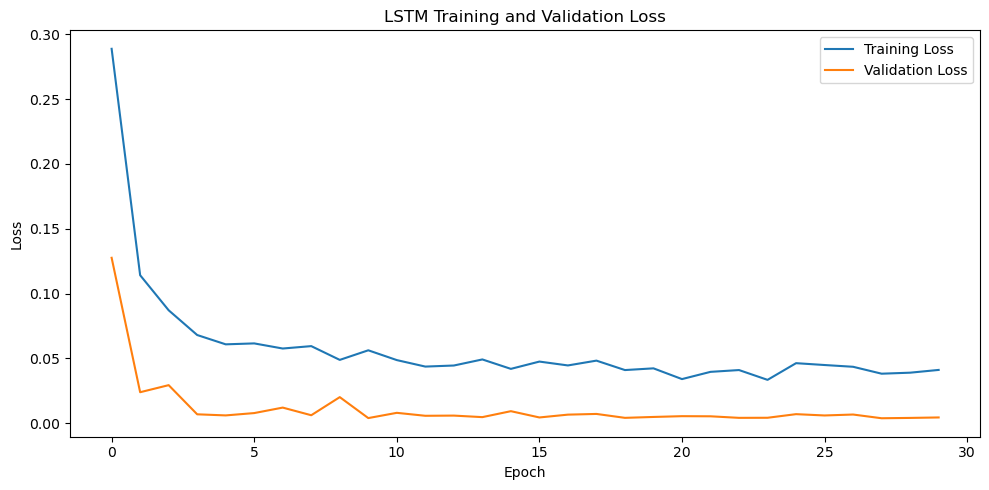

In [70]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# LSTM TEST DATA
# ============================================================

all_close = df_fe[["Close"]].values

all_close_scaled = close_scaler.transform(
    all_close
)

test_start_index = len(train_df)

lstm_test_data = all_close_scaled[
    test_start_index - 30:
]

X_lstm_test = []
y_lstm_test = []

for i in range(
    30,
    len(lstm_test_data)
):

    X_lstm_test.append(
        lstm_test_data[i-30:i, 0]
    )

    y_lstm_test.append(
        lstm_test_data[i, 0]
    )

X_lstm_test = np.array(
    X_lstm_test
)

y_lstm_test = np.array(
    y_lstm_test
)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

print(
    "LSTM Test X:",
    X_lstm_test.shape
)

LSTM Test X: (252, 30, 1)


In [72]:
lstm_pred_scaled = lstm_model.predict(
    X_lstm_test
)

lstm_pred = close_scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

lstm_actual = close_scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

lstm_result = evaluate_model(
    "LSTM",
    lstm_actual,
    lstm_pred
)

print("LSTM Results:")
print(lstm_result)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step
LSTM Results:
{'Model': 'LSTM', 'MAE': 17.741058170421784, 'MSE': 455.46322006207765, 'RMSE': np.float64(21.34158429128629), 'MAPE': np.float64(5.092117154304845), 'R2': 0.8564320837007063}


# FINAL MODEL COMPARISON

All five models are compared using the same evaluation metrics.

The model with the lowest RMSE is selected as the best model.

In [73]:
final_results = pd.DataFrame([
    lr_result,
    rf_best_result,
    xgb_best_result,
    arima_result,
    lstm_result
])

final_results = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(final_results)

,Model,MAE,MSE,RMSE,MAPE,R2
0,Linear Regression,7.124895,89.017241,9.434895,2.070923,0.971397
1,LSTM,17.741058,455.463220,21.341584,5.092117,0.856432
2,Random Forest Tuned,41.013991,2131.278728,46.165774,12.155957,0.315179
3,XGBoost Tuned,36.183295,2216.368139,47.078319,10.977538,0.287838
4,ARIMA,133.415496,20971.552787,144.815582,35.908027,-5.610506


## Model Comparison — Observations
| Model | RMSE | MAPE | R² | Interpretation |
|---|---:|---:|---:|---|
| **Linear Regression** | **9.43** | **2.07%** | **0.971** | Best on the held-out test period |
| LSTM | 21.34 | 5.09% | 0.856 | Second-best; captures nonlinear sequence patterns but did not outperform LR |
| Random Forest Tuned | 46.17 | 12.16% | 0.315 | Weaker than LR and LSTM on this test period |
| XGBoost Tuned | 47.08 | 10.98% | 0.288 | Did not outperform the simpler linear model |
| ARIMA | 144.82 | 35.91% | -5.611 | Poor performance for this feature/target setup |

### Key Observation
- **Linear Regression is the best-performing tested model on this particular unseen test period**, with the lowest RMSE, lowest MAPE and highest R².
- The result does not mean Linear Regression is universally the best stock model; it means it performed best among these five models on this dataset and test period.
- Because stock prices are non-stationary and market conditions change, the selected model should be re-evaluated when new data becomes available.


In [74]:
best_model_name = final_results.loc[
    0,
    "Model"
]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "\nBest Model:",
    best_model_name
)

print("\nBest Model Performance:")

display(
    final_results.iloc[[0]]
)

BEST MODEL

Best Model: Linear Regression

Best Model Performance:


,Model,MAE,MSE,RMSE,MAPE,R2
0,Linear Regression,7.124895,89.017241,9.434895,2.070923,0.971397


# ACTUAL VS PREDICTED

The following visualization compares the actual closing price with
the XGBoost predictions on the unseen test period.

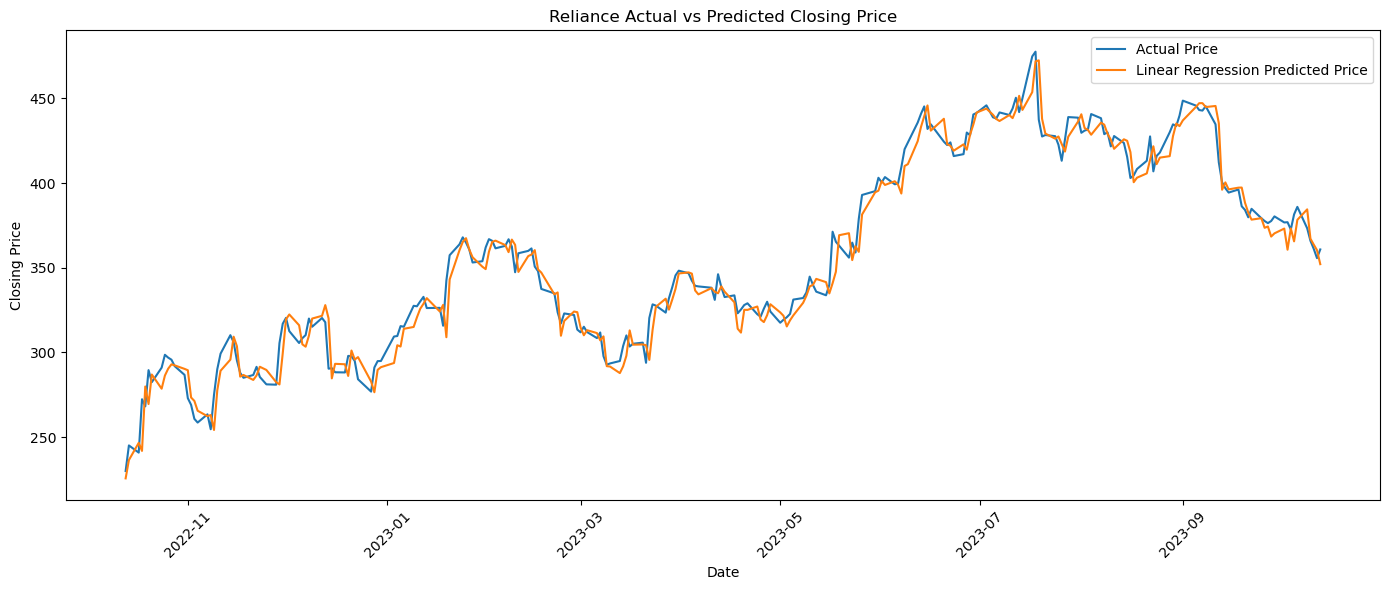

In [75]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df["Date"],
    y_test,
    label="Actual Price"
)

plt.plot(
    test_df["Date"],
    lr_pred,
    label="Linear Regression Predicted Price"
)

plt.title(
    "Reliance Actual vs Predicted Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# RESIDUAL ANALYSIS — FINAL MODEL
Residuals are calculated for the selected Linear Regression model to identify systematic prediction errors.


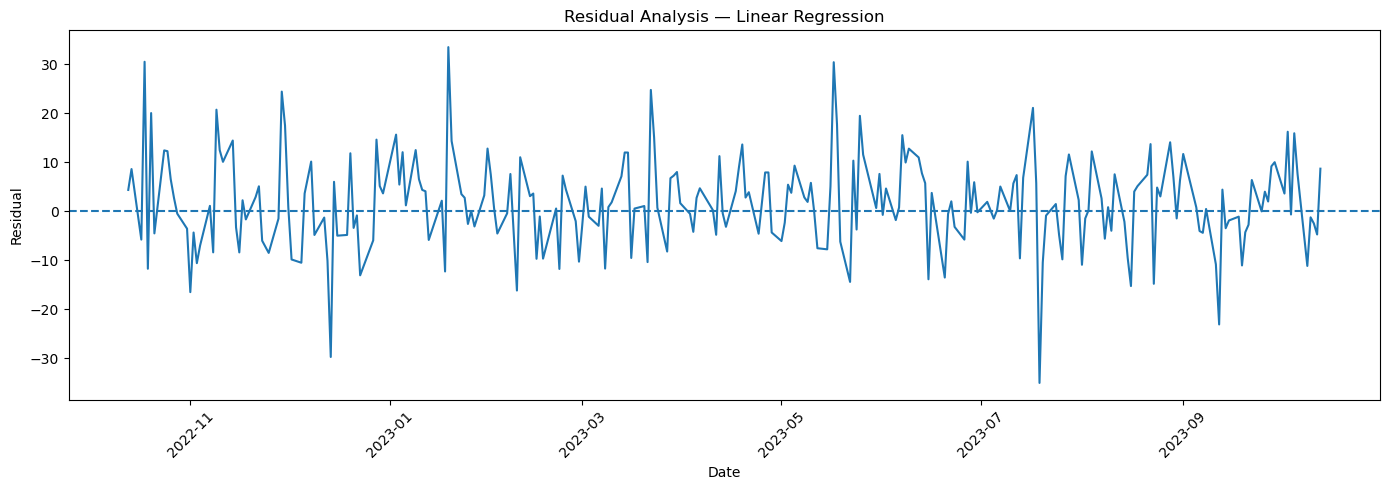

In [76]:
residuals = (
    y_test.values
    -
    lr_pred
)

plt.figure(figsize=(14, 5))

plt.plot(
    test_df["Date"],
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Residual Analysis — Linear Regression"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# FEATURE IMPORTANCE

In [77]:
importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": best_xgb.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

display(importance)

,Feature,Importance
1,High,0.459589
0,Open,0.202474
3,Close,0.194775
12,MA_20,0.078163
2,Low,0.028868
11,MA_10,0.021102
20,MACD_Signal,0.004822
30,Month,0.001781
6,Close_Lag1,0.001755
13,MA_50,0.001191


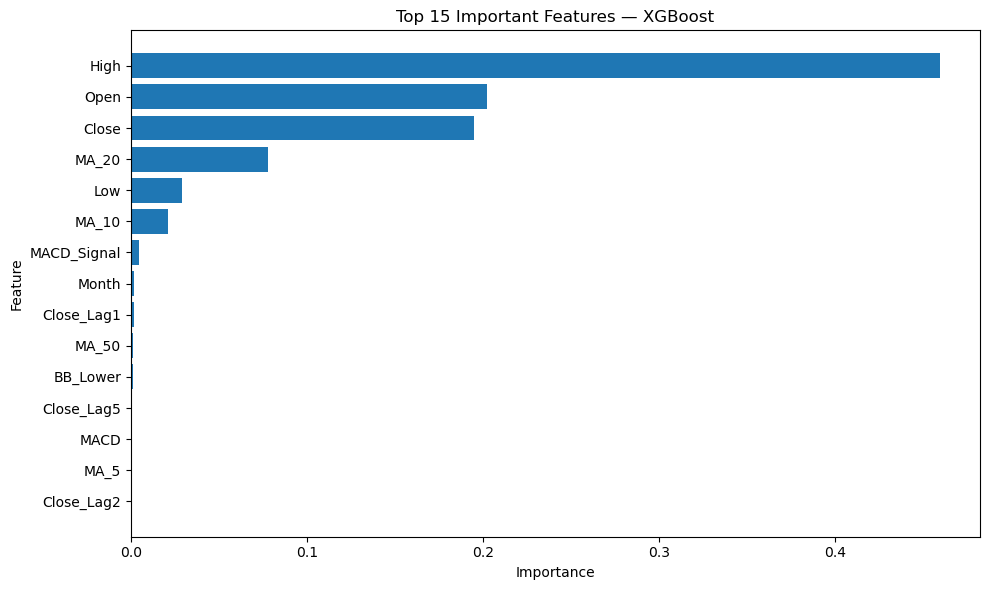

In [78]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Important Features — XGBoost"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# SHORT-TERM AND LONG-TERM TREND

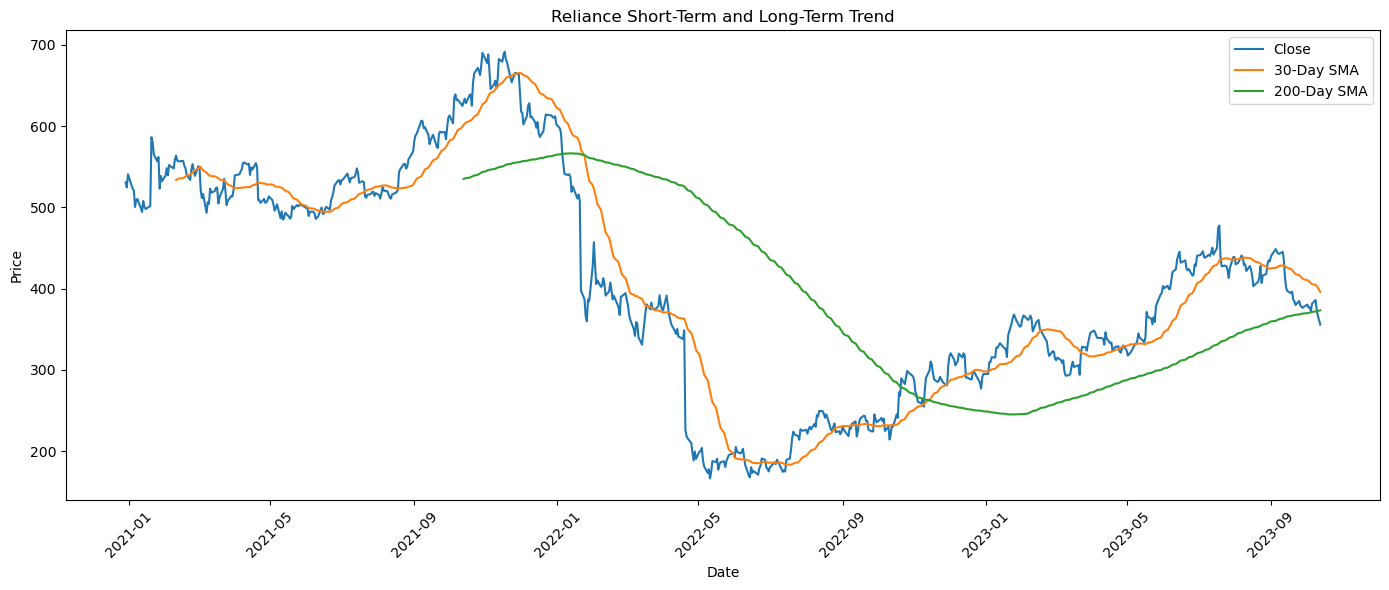

In [79]:
df_fe["SMA_30"] = (
    df_fe["Close"]
    .rolling(30)
    .mean()
)

df_fe["SMA_200"] = (
    df_fe["Close"]
    .rolling(200)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    df_fe["Date"],
    df_fe["Close"],
    label="Close"
)

plt.plot(
    df_fe["Date"],
    df_fe["SMA_30"],
    label="30-Day SMA"
)

plt.plot(
    df_fe["Date"],
    df_fe["SMA_200"],
    label="200-Day SMA"
)

plt.title(
    "Reliance Short-Term and Long-Term Trend"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [80]:
df["Target"] = df["Close"]

In [81]:
df["Target"] = df["Close"].shift(-1)

## Check Features and Target

Before using the final model, I am checking the features used for prediction and making sure that the target variable is not included in the input features.

In [82]:
print("Number of features:", len(X.columns))

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget present in features:", y.name in X.columns)

Number of features: 35

Features:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'EMA_20', 'Daily_Return', 'Volatility_10', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower', 'High_Low_Range', 'Open_Close_Range', 'Volume_MA_10', 'Volume_Change', 'Day_of_Week', 'Month', 'Quarter', 'Daily_Range_Pct', 'Open_Close_Return', 'Volume_Ratio']

Target:
Target

Target present in features: False


In [83]:
print("Feature columns:")
for col in X.columns:
    print(col)

Feature columns:
Open
High
Low
Close
Adj Close
Volume
Close_Lag1
Close_Lag2
Close_Lag3
Close_Lag5
MA_5
MA_10
MA_20
MA_50
EMA_20
Daily_Return
Volatility_10
Volatility_20
RSI_14
MACD
MACD_Signal
BB_Mid
BB_Std
BB_Upper
BB_Lower
High_Low_Range
Open_Close_Range
Volume_MA_10
Volume_Change
Day_of_Week
Month
Quarter
Daily_Range_Pct
Open_Close_Return
Volume_Ratio


# Actual vs Predicted

The following graph compares the actual closing price with the closing price predicted by the Linear Regression model.

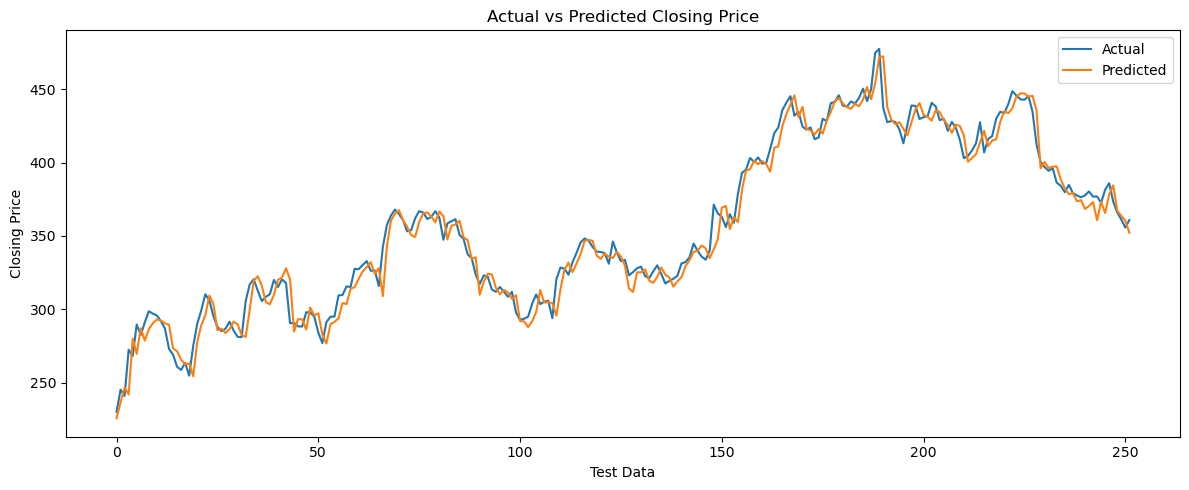

In [84]:
lr_pred = lr_model.predict(X_test_scaled)

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lr_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Test Data")
plt.ylabel("Closing Price")

plt.legend()
plt.tight_layout()
plt.show()

## Actual vs Predicted Values

The first few actual and predicted values are displayed to compare the model predictions with the actual closing prices.

In [85]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_pred
})

comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Error
0,230.000000,225.640955,4.359045
1,245.100006,236.484726,8.615280
2,240.860001,246.638409,-5.778408
3,272.380005,241.861211,30.518794
4,268.160004,279.894747,-11.734743
5,289.570007,269.523512,20.046495
6,282.450012,286.965960,-4.515948
7,291.019989,278.594039,12.425950
8,298.619995,286.355015,12.264980
9,296.940002,290.407167,6.532835


## Prediction Error

The prediction error is calculated as the difference between the actual and predicted closing prices.

In [86]:
comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

comparison.head(10)

,Actual,Predicted,Error,Absolute_Error
0,230.000000,225.640955,4.359045,4.359045
1,245.100006,236.484726,8.615280,8.615280
2,240.860001,246.638409,-5.778408,5.778408
3,272.380005,241.861211,30.518794,30.518794
4,268.160004,279.894747,-11.734743,11.734743
5,289.570007,269.523512,20.046495,20.046495
6,282.450012,286.965960,-4.515948,4.515948
7,291.019989,278.594039,12.425950,12.425950
8,298.619995,286.355015,12.264980,12.264980
9,296.940002,290.407167,6.532835,6.532835


In [87]:
print("Mean Absolute Error:",
      comparison["Absolute_Error"].mean())

print("Maximum Absolute Error:",
      comparison["Absolute_Error"].max())

print("Minimum Absolute Error:",
      comparison["Absolute_Error"].min())

Mean Absolute Error: 7.124895434789507
Maximum Absolute Error: 35.04204479551032
Minimum Absolute Error: 0.021620671038135697


## Residual Analysis

Residuals show the difference between the actual and predicted closing prices.

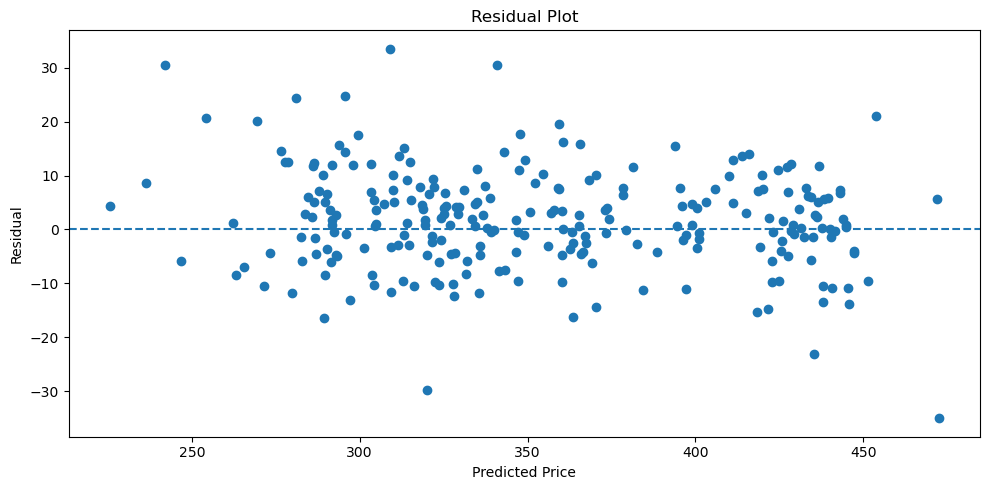

In [88]:
residuals = y_test.values - lr_pred

plt.figure(figsize=(10, 5))

plt.scatter(
    lr_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

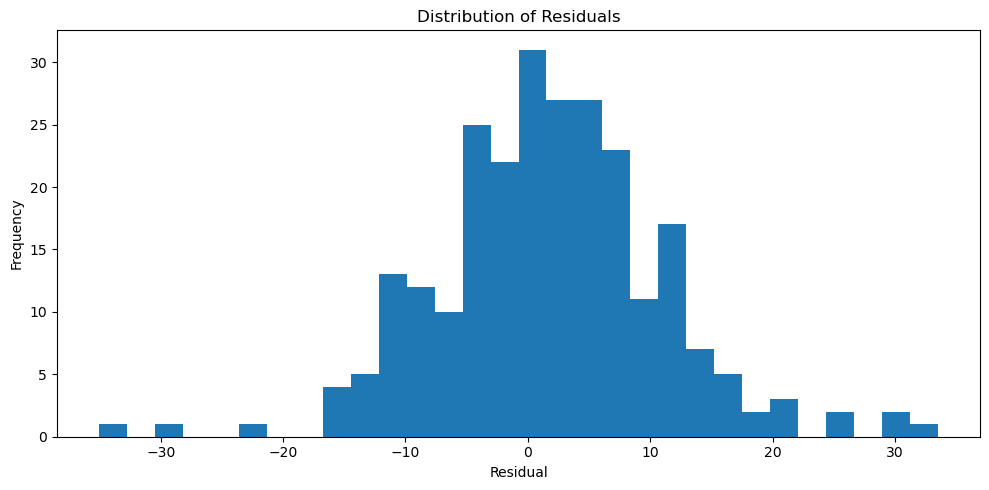

In [89]:
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [90]:
print("Mean Residual:", residuals.mean())

Mean Residual: 1.7558289675902115


## Model Comparison

The RMSE values of all the tested models are compared below.

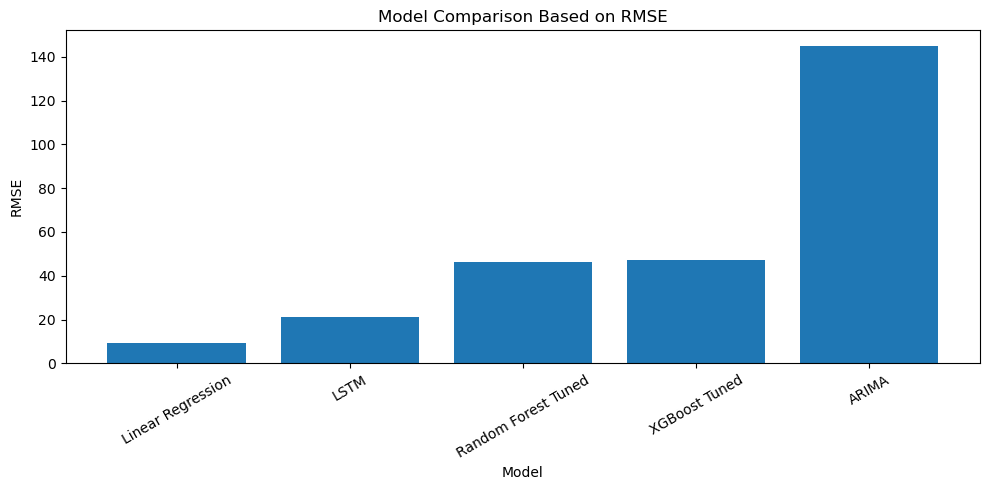

In [91]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["Model"],
    final_results["RMSE"]
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Final Model Selection

Based on the model evaluation results, Linear Regression produced the lowest RMSE among the tested models.

Therefore, Linear Regression is selected as the final model for the next-day closing price prediction.

# Next-Day Price Prediction

The selected Linear Regression model is used to generate a prediction using the latest available feature values.

In [92]:
latest_data = X.iloc[[-1]]

latest_scaled = scaler.transform(
    latest_data
)

next_day_prediction = lr_model.predict(
    latest_scaled
)

print(
    "Predicted next-day closing price:",
    next_day_prediction[0]
)

Predicted next-day closing price: 352.1239171695178


# Save Final Model

The final Linear Regression model is saved so that it can be reused later without training the model again.

In [93]:
import joblib

joblib.dump(
    lr_model,
    "reliance_linear_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [94]:
joblib.dump(
    scaler,
    "reliance_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [95]:
joblib.dump(
    list(X.columns),
    "reliance_features.pkl"
)

print("Feature names saved successfully.")

Feature names saved successfully.


# Load Saved Model

The saved model and scaler are loaded again to check whether they can be used for prediction.

In [96]:
loaded_model = joblib.load(
    "reliance_linear_regression.pkl"
)

loaded_scaler = joblib.load(
    "reliance_scaler.pkl"
)

loaded_features = joblib.load(
    "reliance_features.pkl"
)

print("Model loaded successfully.")
print("Scaler loaded successfully.")
print("Features loaded successfully.")

Model loaded successfully.
Scaler loaded successfully.
Features loaded successfully.


In [97]:
test_input = X.iloc[[-1]]

test_input_scaled = loaded_scaler.transform(
    test_input
)

saved_model_prediction = loaded_model.predict(
    test_input_scaled
)

print(
    "Prediction from saved model:",
    saved_model_prediction[0]
)

Prediction from saved model: 352.1239171695178


In [98]:
import joblib

joblib.dump(lr_model, "reliance_linear_regression.pkl")
joblib.dump(scaler, "reliance_scaler.pkl")
joblib.dump(list(X.columns), "reliance_features.pkl")

['reliance_features.pkl']

# 30-DAY FUTURE PRICE FORECAST

Everything above trains and evaluates models to predict only the **next single trading day**. The business objective for this project is to forecast the **next 30 trading days**, so this section extends the best-performing model (Linear Regression, chosen in the Final Model Selection step above) into a full 30-day forecast, and cross-checks it against a direct multi-step ARIMA forecast.

## Optional — Fetch 2015–2022 Data From the Web

The assignment brief asks for Open/High/Low/Close data **from 2015 to 2022, obtained from the web**. The dataset currently loaded above (`Company stock prices.xlsx`) covers October 2020–2023 from a local file. If you want data that matches the brief exactly, run the cell below instead (it uses Yahoo Finance and needs `pip install yfinance`) and use the resulting `df` in place of the Excel-loaded one — everything else in the notebook works unchanged since the column names match.

This cell is **optional** and does not change anything above it; skip it if your local Excel file already satisfies your instructor's requirement.

In [99]:
# OPTIONAL: fetch Reliance Industries (RELIANCE.NS) OHLCV data for 2015-2022 from Yahoo Finance
# Uncomment and run if you need data matching the 2015-2022 assignment brief.

# import yfinance as yf
#
# df = yf.download("RELIANCE.NS", start="2015-01-01", end="2022-12-31")
# df = df.reset_index()
# df = df.rename(columns={"Adj Close": "Adj Close"})  # column already named correctly
# df["Date"] = pd.to_datetime(df["Date"])
# print(df.shape)
# df.head()


## Approach: Recursive (Iterative) Forecasting

The Linear Regression model was trained on engineered features (lag prices, moving averages, RSI, MACD, Bollinger Bands, volume ratios, etc.) that only exist once a day's actual Open, High, Low, Close and Volume are known.

To project 30 days into the future we don't have real future OHLCV values yet, so we forecast **one day at a time**:

1. Predict the next day's Close using the latest known features.
2. Treat that predicted Close as if it were the actual close for that day (Open ≈ High ≈ Low ≈ predicted Close, Volume ≈ the recent 10-day average volume).
3. Recompute all technical indicators, now including this new day.
4. Predict the following day, and repeat for 30 steps.

**Caveat:** because each day's forecast is built on the *previous day's prediction* rather than a real observation, small errors compound the further out we forecast. This is a well-known limitation of recursive forecasting with single-step regression models, which is why an ARIMA multi-step forecast is generated afterwards for comparison.

In [100]:
# ============================================================
# REUSABLE FEATURE-ENGINEERING FUNCTION
# ============================================================
# This mirrors, step for step, the feature engineering done earlier in the
# notebook (lag prices, moving averages, EMA, returns, volatility, RSI,
# MACD, Bollinger Bands, price ranges, volume features and date features),
# but wrapped in a function so it can be re-run each time a new
# (predicted) day is appended to the price history.

def build_technical_features(data):
    data = data.copy()
    data = data.sort_values("Date").reset_index(drop=True)

    # Lag features
    data["Close_Lag1"] = data["Close"].shift(1)
    data["Close_Lag2"] = data["Close"].shift(2)
    data["Close_Lag3"] = data["Close"].shift(3)
    data["Close_Lag5"] = data["Close"].shift(5)

    # Moving averages
    data["MA_5"]  = data["Close"].rolling(5).mean()
    data["MA_10"] = data["Close"].rolling(10).mean()
    data["MA_20"] = data["Close"].rolling(20).mean()
    data["MA_50"] = data["Close"].rolling(50).mean()

    # Exponential moving average
    data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

    # Daily return and rolling volatility
    data["Daily_Return"] = data["Close"].pct_change()
    data["Volatility_10"] = data["Daily_Return"].rolling(10).std()
    data["Volatility_20"] = data["Daily_Return"].rolling(20).std()

    # RSI (14-day)
    delta = data["Close"].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    data["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD (12, 26, 9)
    ema12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema26 = data["Close"].ewm(span=26, adjust=False).mean()
    data["MACD"] = ema12 - ema26
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

    # Bollinger Bands (20-day, 2 std)
    data["BB_Mid"] = data["Close"].rolling(20).mean()
    data["BB_Std"] = data["Close"].rolling(20).std()
    data["BB_Upper"] = data["BB_Mid"] + (2 * data["BB_Std"])
    data["BB_Lower"] = data["BB_Mid"] - (2 * data["BB_Std"])

    # Price range features
    data["High_Low_Range"] = data["High"] - data["Low"]
    data["Open_Close_Range"] = data["Close"] - data["Open"]

    # Volume-based features
    data["Volume_MA_10"] = data["Volume"].rolling(10).mean()
    data["Volume_Change"] = data["Volume"].pct_change()

    # Date-based features
    data["Day_of_Week"] = data["Date"].dt.dayofweek
    data["Month"] = data["Date"].dt.month
    data["Quarter"] = data["Date"].dt.quarter

    # Additional features used later in the notebook
    data["Daily_Range_Pct"] = ((data["High"] - data["Low"]) / data["Close"]) * 100
    data["Open_Close_Return"] = ((data["Close"] - data["Open"]) / data["Open"]) * 100
    data["Volume_Ratio"] = data["Volume"] / data["Volume_MA_10"]

    return data

print("build_technical_features() ready.")


build_technical_features() ready.


In [101]:
# ============================================================
# RECURSIVE 30-DAY FORECAST USING THE BEST MODEL (LINEAR REGRESSION)
# ============================================================

N_DAYS_AHEAD = 30

# Start from clean OHLCV history only (decoupled from any extra columns
# added to `df` earlier in the notebook)
history = df[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()
history["Date"] = pd.to_datetime(history["Date"])

future_dates = pd.bdate_range(
    start=history["Date"].max() + pd.Timedelta(days=1),
    periods=N_DAYS_AHEAD
)

working = history.copy()
lr_forecast_records = []

for future_date in future_dates:

    prev_close = working["Close"].iloc[-1]
    prev_vol_avg = working["Volume"].tail(10).mean()

    # Placeholder row for the new day — Open/High/Low/Adj Close start out
    # equal to the previous close, Volume uses the recent 10-day average.
    # Close is filled in below once the model has made its prediction.
    new_row = pd.DataFrame({
        "Date": [future_date],
        "Open": [prev_close],
        "High": [prev_close],
        "Low": [prev_close],
        "Close": [prev_close],
        "Adj Close": [prev_close],
        "Volume": [prev_vol_avg],
    })

    working = pd.concat([working, new_row], ignore_index=True)

    feat_df = build_technical_features(working)
    latest_features = feat_df[model_features].iloc[[-1]]

    latest_scaled = scaler.transform(latest_features)
    next_close_pred = lr_model.predict(latest_scaled)[0]

    # Update the placeholder day with the model's actual prediction
    last_idx = working.index[-1]
    working.loc[last_idx, "Close"] = next_close_pred
    working.loc[last_idx, "Adj Close"] = next_close_pred
    working.loc[last_idx, "High"] = max(prev_close, next_close_pred)
    working.loc[last_idx, "Low"] = min(prev_close, next_close_pred)

    lr_forecast_records.append({"Date": future_date, "Predicted_Close_LR": next_close_pred})

forecast_30_lr = pd.DataFrame(lr_forecast_records)

print("Linear Regression 30-day recursive forecast:")
display(forecast_30_lr)


Linear Regression 30-day recursive forecast:


,Date,Predicted_Close_LR
0,2023-10-17,356.787036
1,2023-10-18,354.802221
2,2023-10-19,350.009264
3,2023-10-20,344.215848
4,2023-10-23,337.989124
5,2023-10-24,331.545366
6,2023-10-25,325.330284
7,2023-10-26,317.083310
8,2023-10-27,307.245156
9,2023-10-30,296.913384


## Cross-Check: Direct 30-Day ARIMA Forecast

In [102]:
# ============================================================
# ARIMA — DIRECT 30-DAY FORECAST (fit on the FULL Close history)
# ============================================================
# Unlike the recursive Linear Regression approach above, ARIMA forecasts
# multiple steps ahead directly from the model's own equation, so its
# errors do not compound in the same step-by-step way.

arima_full_model = ARIMA(
    df_fe.set_index("Date")["Close"],
    order=(5, 1, 0)
)
arima_full_fit = arima_full_model.fit()

arima_forecast_obj = arima_full_fit.get_forecast(steps=N_DAYS_AHEAD)
arima_30_mean = arima_forecast_obj.predicted_mean
arima_30_ci = arima_forecast_obj.conf_int(alpha=0.05)

forecast_30_arima = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Close_ARIMA": arima_30_mean.values,
    "ARIMA_Lower_95": arima_30_ci.iloc[:, 0].values,
    "ARIMA_Upper_95": arima_30_ci.iloc[:, 1].values,
})

print("ARIMA 30-day forecast:")
display(forecast_30_arima)


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA 30-day forecast:


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Date,Predicted_Close_ARIMA,ARIMA_Lower_95,ARIMA_Upper_95
0,2023-10-17,355.596870,332.568314,378.625427
1,2023-10-18,355.946488,322.733868,389.159107
2,2023-10-19,356.055005,315.323220,396.786790
3,2023-10-20,356.259631,308.920128,403.599135
4,2023-10-23,356.362985,303.461039,409.264931
5,2023-10-24,356.359089,298.596477,414.121701
6,2023-10-25,356.354172,294.109285,418.599059
7,2023-10-26,356.349940,289.929198,422.770683
8,2023-10-27,356.344042,285.997220,426.690864
9,2023-10-30,356.342236,282.271472,430.413000


## Plot: Historical Price + 30-Day Forecast

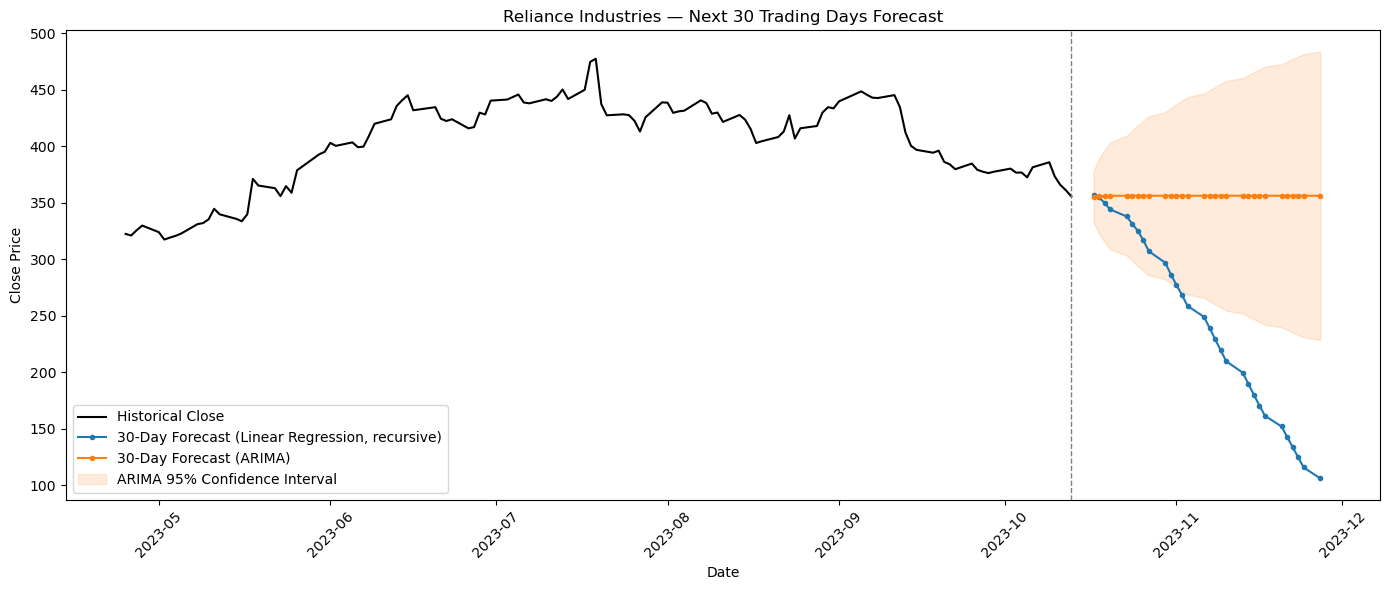

In [103]:
plt.figure(figsize=(14, 6))

# Last 120 trading days of history for context
recent_history = df_fe.tail(120)
plt.plot(recent_history["Date"], recent_history["Close"], label="Historical Close", color="black")

plt.plot(forecast_30_lr["Date"], forecast_30_lr["Predicted_Close_LR"],
         label="30-Day Forecast (Linear Regression, recursive)", color="tab:blue", marker="o", markersize=3)

plt.plot(forecast_30_arima["Date"], forecast_30_arima["Predicted_Close_ARIMA"],
         label="30-Day Forecast (ARIMA)", color="tab:orange", marker="o", markersize=3)

plt.fill_between(forecast_30_arima["Date"], forecast_30_arima["ARIMA_Lower_95"], forecast_30_arima["ARIMA_Upper_95"],
                  color="tab:orange", alpha=0.15, label="ARIMA 95% Confidence Interval")

plt.axvline(df_fe["Date"].max(), linestyle="--", color="gray", linewidth=1)

plt.title("Reliance Industries — Next 30 Trading Days Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Short-Term vs Long-Term Trend Check

In [104]:
last_close = df_fe["Close"].iloc[-1]
last_sma_30 = df_fe["SMA_30"].iloc[-1]
last_sma_200 = df_fe["SMA_200"].iloc[-1]
day30_lr = forecast_30_lr["Predicted_Close_LR"].iloc[-1]
day30_arima = forecast_30_arima["Predicted_Close_ARIMA"].iloc[-1]

print("=" * 70)
print("SHORT-TERM VS LONG-TERM TREND CHECK")
print("=" * 70)
print(f"Latest actual Close        : {last_close:.2f}")
print(f"30-Day SMA (short-term)    : {last_sma_30:.2f}")
print(f"200-Day SMA (long-term)    : {last_sma_200:.2f}")
print(f"Forecast Close, Day 30 (LR)   : {day30_lr:.2f}")
print(f"Forecast Close, Day 30 (ARIMA): {day30_arima:.2f}")
print()

short_term_trend = "uptrend" if last_close > last_sma_30 else "downtrend"
long_term_trend = "uptrend" if last_close > last_sma_200 else "downtrend"
forecast_trend_lr = "up" if day30_lr > last_close else "down"
forecast_trend_arima = "up" if day30_arima > last_close else "down"

print(f"Current short-term trend (Close vs 30-Day SMA): {short_term_trend}")
print(f"Current long-term trend  (Close vs 200-Day SMA): {long_term_trend}")
print(f"LR forecast direction over next 30 days   : {forecast_trend_lr}")
print(f"ARIMA forecast direction over next 30 days: {forecast_trend_arima}")


SHORT-TERM VS LONG-TERM TREND CHECK
Latest actual Close        : 355.68
30-Day SMA (short-term)    : 395.89
200-Day SMA (long-term)    : 373.27
Forecast Close, Day 30 (LR)   : 106.22
Forecast Close, Day 30 (ARIMA): 356.34

Current short-term trend (Close vs 30-Day SMA): downtrend
Current long-term trend  (Close vs 200-Day SMA): downtrend
LR forecast direction over next 30 days   : down
ARIMA forecast direction over next 30 days: up


## Save the 30-Day Forecast

In [105]:
forecast_combined = forecast_30_lr.merge(forecast_30_arima, on="Date")
forecast_combined.to_csv("reliance_30_day_forecast.csv", index=False)

print("Saved 30-day forecast to reliance_30_day_forecast.csv")
display(forecast_combined)


Saved 30-day forecast to reliance_30_day_forecast.csv


,Date,Predicted_Close_LR,Predicted_Close_ARIMA,ARIMA_Lower_95,ARIMA_Upper_95
0,2023-10-17,356.787036,355.596870,332.568314,378.625427
1,2023-10-18,354.802221,355.946488,322.733868,389.159107
2,2023-10-19,350.009264,356.055005,315.323220,396.786790
3,2023-10-20,344.215848,356.259631,308.920128,403.599135
4,2023-10-23,337.989124,356.362985,303.461039,409.264931
5,2023-10-24,331.545366,356.359089,298.596477,414.121701
6,2023-10-25,325.330284,356.354172,294.109285,418.599059
7,2023-10-26,317.083310,356.349940,289.929198,422.770683
8,2023-10-27,307.245156,356.344042,285.997220,426.690864
9,2023-10-30,296.913384,356.342236,282.271472,430.413000


### Observation — 30-Day Forecast

- Two independent forecasting approaches were used: a **recursive Linear Regression** forecast (rebuilds all technical-indicator features one predicted day at a time) and a **direct multi-step ARIMA** forecast fitted on the full closing-price history.
- Both give an indication of the likely **short-term (30-day) trend**, while the earlier 30-Day/200-Day SMA comparison indicates the **longer-term trend** already in place.
- Agreement between the two 30-day forecasts adds confidence in the direction of the move; disagreement is itself informative and suggests the trend is less certain.
- As noted in the notebook's Limitations section, neither approach accounts for news, earnings, macroeconomic events or market sentiment — all of which materially move Reliance's stock over a 30-day horizon. The forecast should be read as a **statistical extrapolation of past price behavior**, not a guarantee of the actual future price.
- The recursive approach's uncertainty grows with each additional day forecasted, since every step is built on the previous step's *prediction* rather than a real observation; the ARIMA confidence interval widens for the same reason and should be inspected before relying on the point forecast alone.

# Final Conclusion

In this project, historical Reliance Industries stock data was analyzed.

The data was cleaned and explored using different statistical methods and visualizations.

Different features were created from historical stock price and volume data.

Several machine learning and time series models were trained and evaluated.

The tested models included Linear Regression, Random Forest, XGBoost, ARIMA and LSTM.

Based on the evaluation results, Linear Regression achieved the lowest RMSE among the tested models.

Therefore, Linear Regression was selected as the final model for predicting the next-day closing price.

The final model was saved along with the scaler and feature information so that it can be reused for future predictions.

# Limitations

- Stock prices are affected by many external factors.
- The model uses historical market data.
- News and market sentiment are not included.
- Economic conditions are not included.
- The model cannot guarantee the actual future stock price.
- Model performance may change when new market data becomes available.

# Future Scope

The project can be improved in the future by:

- Adding more recent stock data.
- Including NIFTY and SENSEX data.
- Adding news and market sentiment.
- Including more external market factors.
- Testing additional prediction models.
- Updating the model with new data.
- Creating a simple application for users to enter data and get predictions.

### Streamlit Prediction Dashboard

The following screenshot shows the deployed Streamlit application and the prediction generated by the trained Linear Regression model.

In [106]:
from IPython.display import IFrame

IFrame("Reliance Stock Price Prediction.pdf", width=800, height=600)

### 12.1 Prediction Result

The Streamlit application successfully generated the following prediction using the latest available historical data:

| Metric | Value |
|---|---:|
| Latest Date | 16-10-2023 |
| Current Close | ₹360.82 |
| Predicted Close | ₹355.41 |
| Expected Change | -₹5.41 |
| Expected Change (%) | -1.50% |

The model predicts that the next-day closing price may decrease from ₹360.82 to approximately ₹355.41, representing an expected decrease of 1.50%.